# Module 2: Exploratory Data Analysis (EDA)

## NovaMart AI Retail Intelligence Platform

### Overview

This notebook presents the **Exploratory Data Analysis (EDA)** of the integrated NovaMart retail dataset. The objective is to understand the underlying structure of the data, identify purchasing patterns, evaluate business performance, and uncover insights that will support subsequent machine learning and business intelligence modules.

The analysis is performed on the cleaned and integrated master dataset created from the Olist Brazilian E-Commerce database. It combines customer, order, product, payment, seller, review, and geolocation information into a single analytical dataset.

### Objectives

The primary objectives of this exploratory analysis are to:

- Examine the overall structure, quality, and statistical characteristics of the integrated dataset.
- Analyse customer purchasing behaviour and order trends over time.
- Identify the highest-performing product categories based on revenue.
- Evaluate delivery performance by comparing actual and estimated delivery times.
- Investigate customer satisfaction through review score distributions.
- Explore the geographic distribution of customers and sellers across Brazil.
- Analyse customer payment preferences and transaction patterns.
- Examine relationships among numerical variables using correlation analysis.
- Generate actionable business insights that will guide feature engineering, predictive modelling, recommendation systems, anomaly detection, explainable AI, and dashboard development.

### Expected Outcomes

At the end of this notebook, we will have:

- A comprehensive understanding of the NovaMart retail dataset.
- Key business insights into customer behaviour, sales performance, logistics, and payment trends.
- Identification of data patterns, anomalies, and potential outliers.
- Visual evidence supporting feature engineering and machine learning model development.
- A solid analytical foundation for the subsequent modules of the NovaMart AI Retail Intelligence Platform.

# Import Required Libraries

The following libraries are imported to support data manipulation, statistical analysis, and data visualization throughout this exploratory data analysis.

- **Pandas** and **NumPy** for data manipulation and numerical computations.
- **Matplotlib** and **Seaborn** for statistical visualizations.
- **Plotly Express** for interactive charts.
- **Warnings** to suppress unnecessary warning messages for cleaner notebook output.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

# Load the Feature-Engineered Dataset

The feature-engineered dataset generated in the previous module is loaded for exploratory analysis.

This dataset contains the cleaned and integrated retail data together with the engineered business features that will be analysed throughout this notebook.

In [2]:
retail = pd.read_csv(
    "Retail_Featured_Dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("Dataset loaded successfully.")
print(f"Number of Rows    : {retail.shape[0]:,}")
print(f"Number of Columns : {retail.shape[1]}")

Dataset loaded successfully.
Number of Rows    : 113,049
Number of Columns : 50


# Preview the Dataset

Before beginning the analysis, the first few records are displayed to verify that the dataset has been loaded correctly and to gain an initial understanding of its structure.

In [3]:
retail.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,geolocation_zip_code_prefix,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state,processing_days,shipping_days,delivery_delay_days,late_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,72.19,2.0,credit_card,5.0,NaN,"Perfeito, produto entregue antes do combinado.",28013.0,-21.763186,-41.310265,campos dos goytacazes,RJ,-22.497188,-44.127324,volta redonda,RJ,6.0,1.0,-9.0,0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,259.83,3.0,credit_card,4.0,NaN,NaN,15775.0,-20.222506,-50.898951,santa fe do sul,SP,-23.565754,-46.519097,sao paulo,SP,8.0,8.0,-3.0,0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,216.87,5.0,credit_card,5.0,NaN,Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.,35661.0,-19.869998,-44.593059,para de minas,MG,-22.262802,-46.170735,borda da mata,MG,1.0,6.0,-14.0,0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP,25.78,2.0,credit_card,4.0,NaN,NaN,12952.0,-23.105968,-46.590277,atibaia,SP,-20.553651,-47.387145,franca,SP,2.0,4.0,-6.0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR,218.04,3.0,credit_card,5.0,NaN,Gostei pois veio no prazo determinado .,13226.0,-23.243402,-46.827614,varzea paulista,SP,-22.929583,-53.135750,loanda,PR,11.0,13.0,-16.0,0


# Dataset Dimensions

Understanding the size of the dataset provides an indication of the volume of information available for analysis.

The dataset dimensions are reported as:

- Number of observations (rows)
- Number of variables (columns)

In [4]:
print("Rows :", retail.shape[0])
print("Columns :", retail.shape[1])

Rows : 113049
Columns : 50


# Data Structure

This section examines the structure of the dataset by displaying:

- Variable names
- Data types
- Number of non-null observations
- Memory usage

Understanding data types is essential before performing statistical analysis and visualization.

In [5]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113049 entries, 0 to 113048
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113049 non-null  object        
 1   order_item_id                  113049 non-null  int64         
 2   product_id                     113049 non-null  object        
 3   seller_id                      113049 non-null  object        
 4   shipping_limit_date            113049 non-null  object        
 5   price                          113049 non-null  float64       
 6   freight_value                  113049 non-null  float64       
 7   customer_id                    113049 non-null  object        
 8   order_status                   113049 non-null  object        
 9   order_purchase_timestamp       113049 non-null  datetime64[ns]
 10  order_approved_at              113034 non-null  datetime64[ns]
 11  

# Data Types Summary

The following table summarizes the number of variables belonging to each data type.

In [6]:
retail.dtypes.value_counts()

float64           21
object            20
datetime64[ns]     5
int64              4
dtype: int64

# Descriptive Statistics

Descriptive statistics provide an overview of the numerical variables, including:

- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum

These statistics help identify unusual values and understand the distribution of numerical attributes.

In [7]:
retail.describe(include="all").T

,count,unique,top,freq,first,last,mean,std,min,25%,50%,75%,max
order_id,113049,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,113049.0,NaN,NaN,NaN,NaT,NaT,1.198162,0.705208,1.0,1.0,1.0,1.0,21.0
product_id,113049,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,113049,3095,6560211a19b47992c3666cc44a7e94c0,2036,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,113049,93318,2018-03-01 02:50:48,21,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,113049.0,NaN,NaN,NaN,NaT,NaT,120.545169,183.401456,0.85,39.9,74.9,134.9,6735.0
freight_value,113049.0,NaN,NaN,NaN,NaT,NaT,19.986007,15.793141,0.0,13.08,16.26,21.15,409.68
customer_id,113049,98666,fc3d1daec319d62d49bfb5e1f83123e9,21,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,113049,7,delivered,110580,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,113049,98112,2017-07-16 18:19:25,21,2016-09-04 21:15:19,2018-09-03 09:06:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Descriptive Statistics for Categorical Variables

Categorical variables are summarized separately to identify:

- Number of unique categories
- Most frequent category
- Frequency of occurrence

In [8]:
retail.describe(include="object").T

,count,unique,top,freq
order_id,113049,98666,8272b63d03f5f79c56e9e4120aec44ef,21
product_id,113049,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527
seller_id,113049,3095,6560211a19b47992c3666cc44a7e94c0,2036
shipping_limit_date,113049,93318,2018-03-01 02:50:48,21
customer_id,113049,98666,fc3d1daec319d62d49bfb5e1f83123e9,21
order_status,113049,7,delivered,110580
customer_unique_id,113049,95420,c8460e4251689ba205045f3ea17884a1,24
customer_city,113049,4110,sao paulo,17878
customer_state,113049,27,SP,47595
product_category_name,113049,74,cama_mesa_banho,11215


# Missing Value Analysis

Although the dataset has undergone preprocessing, a final assessment of missing values is performed to identify variables with remaining missing observations.

Some missing values are expected because they represent valid business scenarios, such as undelivered orders or customers who chose not to submit reviews.

In [9]:
missing = pd.DataFrame({
    "Missing Values": retail.isnull().sum(),
    "Percentage (%)": round(retail.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"]>0]

missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage (%)
review_comment_title,99616,88.12
review_comment_message,65421,57.87
shipping_days,2471,2.19
delivery_delay_days,2470,2.18
order_delivered_customer_date,2470,2.18
delivery_days,2470,2.18
product_category_name_english,1634,1.45
processing_days,1216,1.08
order_delivered_carrier_date,1201,1.06
review_score,942,0.83


# Duplicate Records

Duplicate records can negatively affect statistical analysis and machine learning models. The following check confirms whether duplicate observations remain in the integrated dataset.

In [10]:
duplicates = retail.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


# Feature Categories

The integrated dataset combines information from multiple business entities.

The available variables can be grouped into the following categories:

- Customer Information
- Order Information
- Product Information
- Seller Information
- Payment Information
- Customer Reviews
- Delivery Information
- Geographic Information

These variables provide a comprehensive representation of NovaMart's retail operations.

In [11]:
pd.DataFrame(retail.columns, columns=["Variables"])

,Variables
0,order_id
1,order_item_id
2,product_id
3,seller_id
4,shipping_limit_date
5,price
6,freight_value
7,customer_id
8,order_status
9,order_purchase_timestamp


# 1. Order Volume Analysis

Understanding customer purchasing behaviour over time is essential for identifying business growth, seasonal demand, and sales trends.

This section analyses the monthly order volume across the observation period.

In [12]:
orders_month = (
    retail.groupby(
        retail["order_purchase_timestamp"].dt.to_period("M")
    )["order_id"]
    .nunique()
    .reset_index(name="Number of Orders")
)

orders_month["order_purchase_timestamp"] = (
    orders_month["order_purchase_timestamp"].astype(str)
)

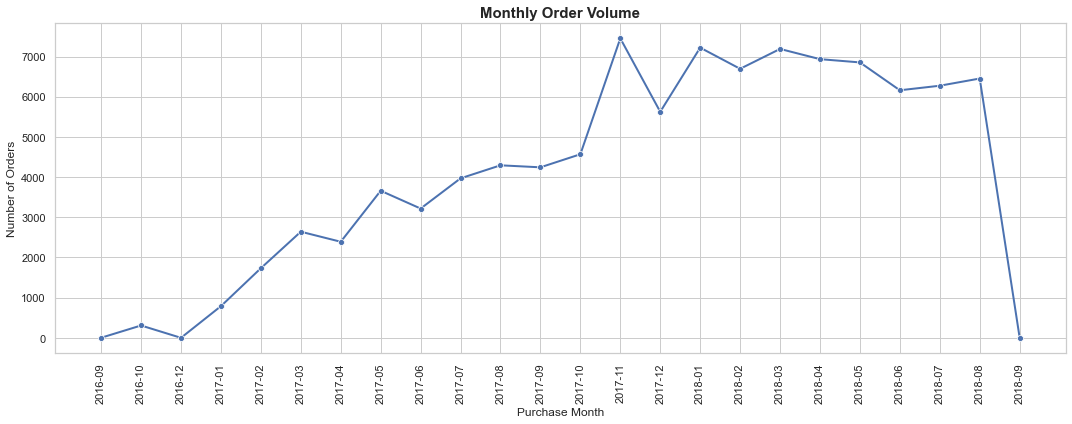

In [13]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=orders_month,
    x="order_purchase_timestamp",
    y="Number of Orders",
    marker="o",
    linewidth=2
)

plt.xticks(rotation=90)

plt.title(
    "Monthly Order Volume",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [14]:
plt.savefig("images/order_volume_trend.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

### Interpretation

The monthly order volume reveals a clear upward growth trend in NovaMart's sales activity over the observation period.

During the early months (September 2016 to early 2017), the platform recorded relatively few orders, reflecting the initial stage of business operations and customer adoption. Beginning in mid-2017, monthly order volume increased steadily, indicating sustained growth in customer demand and successful business expansion.

A significant increase in orders is observed in **November 2017**, where monthly purchases reached their highest level. This spike is likely associated with major promotional events such as **Black Friday**, which traditionally generate substantial increases in online shopping activity.

Following November 2017, order volumes remained consistently high throughout 2018, generally fluctuating between **6,000 and 7,200 orders per month**. This stability suggests that NovaMart maintained a strong customer base and consistent sales performance after its rapid growth phase.

The sharp decline observed in **September 2018** should **not** be interpreted as a reduction in business performance. The Olist dataset contains only a partial record for this month because data collection ended before the month was complete. Consequently, September 2018 represents an incomplete reporting period and should be excluded when analysing long-term sales trends.

Overall, the visualization indicates that NovaMart experienced strong and sustained business growth, with evidence of seasonal demand patterns and a stable order volume during the mature stage of operations.

### Business Insights

- Customer demand increased steadily throughout the study period, indicating continuous business growth.
- Promotional periods, particularly November 2017, generated exceptionally high order volumes.
- Monthly order volumes remained relatively stable during 2018, suggesting a mature and loyal customer base.
- Seasonal peaks should be considered when planning inventory, logistics, and marketing campaigns.
- The incomplete data for September 2018 should be excluded from forecasting models to avoid introducing bias.

## Time-Series Analysis

The NovaMart retail dataset includes transaction records up to **September 2018**. However, September 2018 contains only a partial month of data because data collection ended before the month was complete.

To avoid biased interpretations of monthly trends and seasonality, analyses involving monthly order volume, revenue trends, and time-series forecasting exclude September 2018. The complete dataset is retained for all other analyses.

In [15]:
# Create a copy for time-series analyses only
retail_time = retail[
    retail["order_purchase_timestamp"] < "2018-09-01"
].copy()

print("Time-series dataset shape:", retail_time.shape)

Time-series dataset shape: (113048, 50)


In [16]:
# Calculate monthly order volume
orders_month = (
    retail_time
    .groupby(retail_time["order_purchase_timestamp"].dt.to_period("M"))
    ["order_id"]
    .nunique()
    .reset_index(name="Number of Orders")
)

# Convert Period to string for plotting
orders_month["order_purchase_timestamp"] = (
    orders_month["order_purchase_timestamp"].astype(str)
)

orders_month.head()

,order_purchase_timestamp,Number of Orders
0,2016-09,3
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733


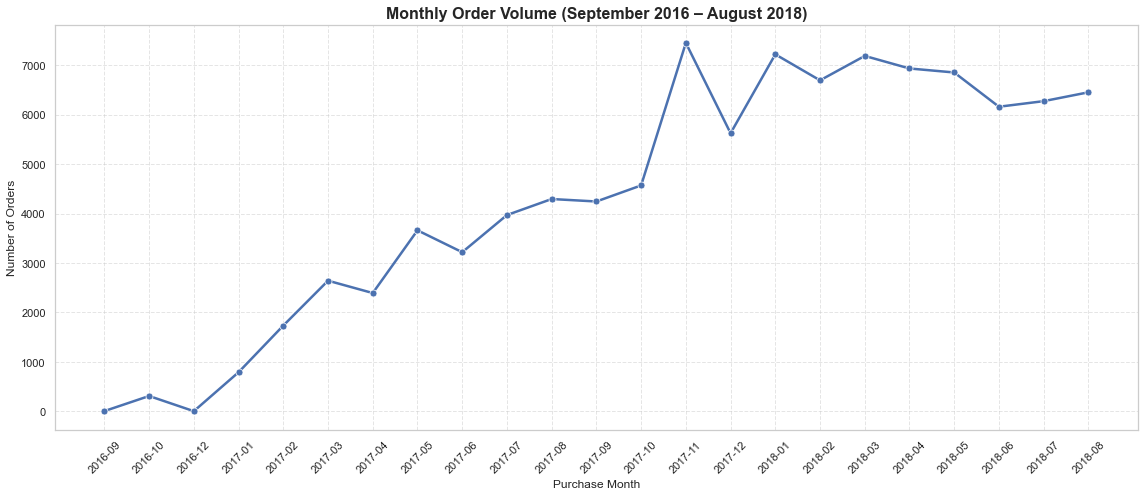

In [17]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=orders_month,
    x="order_purchase_timestamp",
    y="Number of Orders",
    marker="o",
    linewidth=2.5,
    markersize=7
)

plt.title(
    "Monthly Order Volume (September 2016 – August 2018)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Purchase Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

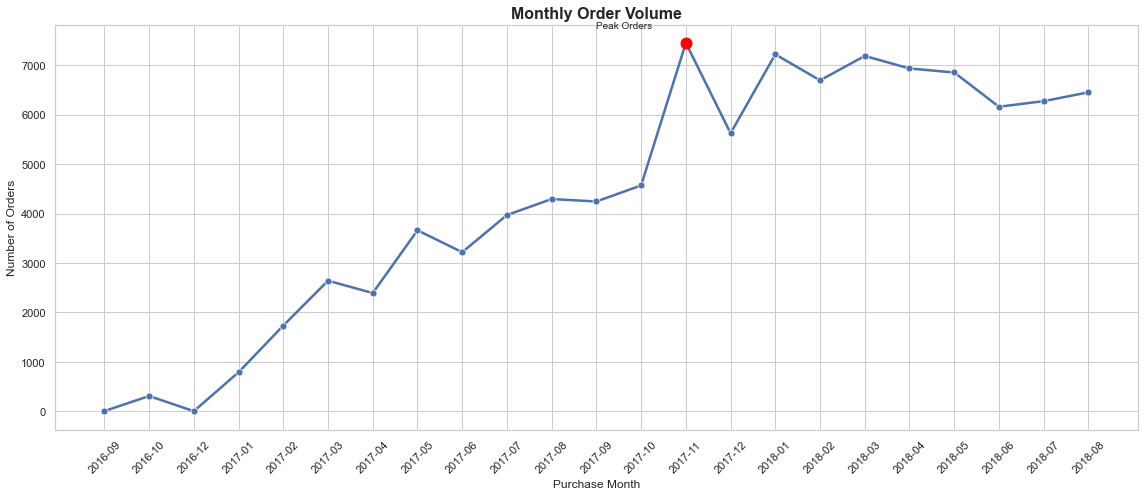

In [18]:
plt.figure(figsize=(16,7))

ax = sns.lineplot(
    data=orders_month,
    x="order_purchase_timestamp",
    y="Number of Orders",
    marker="o",
    linewidth=2.5,
    markersize=7
)

# Highlight the highest month
peak = orders_month["Number of Orders"].idxmax()

plt.scatter(
    peak,
    orders_month.loc[peak, "Number of Orders"],
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    "Peak Orders",
    xy=(peak, orders_month.loc[peak, "Number of Orders"]),
    xytext=(peak-2, orders_month["Number of Orders"].max()+300),
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Monthly Order Volume",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [19]:
plt.savefig("images/order_volume_trend.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

### Interpretation

The monthly order volume shows a strong upward trend throughout the study period, indicating continuous business growth and increasing customer adoption.

Order volumes increased steadily from early 2017, reaching a pronounced peak in **November 2017**. This surge is consistent with seasonal promotional events such as **Black Friday**, which typically drive significant increases in online purchases.

Following this peak, monthly orders remained consistently high throughout 2018, fluctuating between approximately **6,000 and 7,200 orders per month**. This suggests that NovaMart maintained a stable customer base and sustained sales performance after its rapid growth phase.

The incomplete transaction records for **September 2018** were excluded from this analysis to prevent distortion of monthly trends and ensure an accurate representation of business performance.

# 2. Monthly Revenue Trend

Revenue is one of the most important indicators of business performance. While order volume measures customer activity, revenue reflects the financial success of the business.

This section analyses NovaMart's monthly revenue to identify growth trends, seasonal fluctuations, and periods of exceptional sales performance.

Similar to the previous analysis, **September 2018 is excluded** because it represents an incomplete reporting period and would underestimate monthly revenue.

In [20]:
# Calculate monthly revenue

monthly_revenue = (
    retail_time
    .groupby(retail_time["order_purchase_timestamp"].dt.to_period("M"))
    ["payment_value"]
    .sum()
    .reset_index(name="Monthly Revenue")
)

# Convert Period to string
monthly_revenue["order_purchase_timestamp"] = (
    monthly_revenue["order_purchase_timestamp"].astype(str)
)

monthly_revenue.head()

,order_purchase_timestamp,Monthly Revenue
0,2016-09,347.52
1,2016-10,74353.46
2,2016-12,19.62
3,2017-01,187865.53
4,2017-02,345640.05


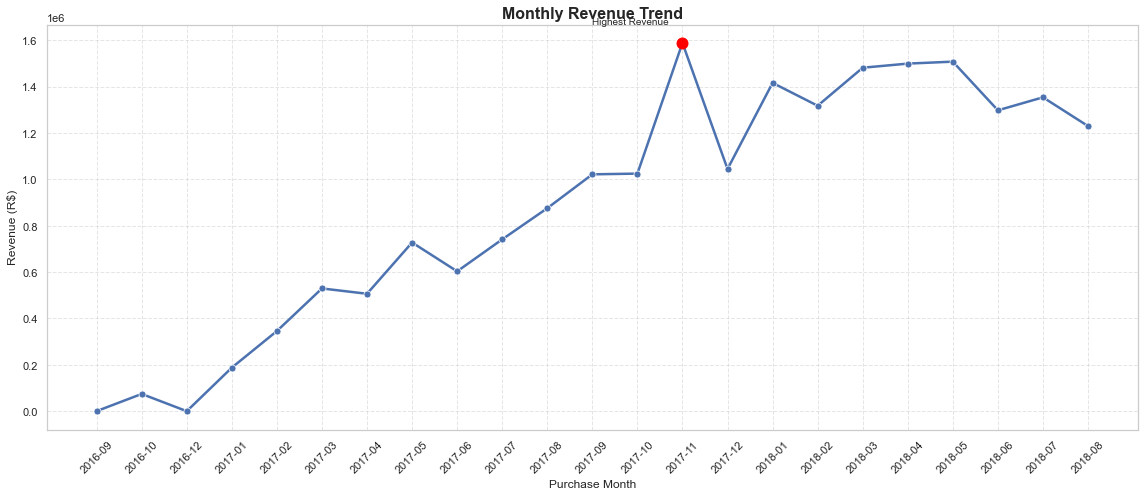

In [21]:
plt.figure(figsize=(16,7))

ax = sns.lineplot(
    data=monthly_revenue,
    x="order_purchase_timestamp",
    y="Monthly Revenue",
    marker="o",
    linewidth=2.5,
    markersize=7
)

# Highest revenue month
peak = monthly_revenue["Monthly Revenue"].idxmax()

plt.scatter(
    peak,
    monthly_revenue.loc[peak, "Monthly Revenue"],
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    "Highest Revenue",
    xy=(peak, monthly_revenue.loc[peak, "Monthly Revenue"]),
    xytext=(peak-2,
            monthly_revenue["Monthly Revenue"].max()*1.05),
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Purchase Month")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [22]:
#Monthly Revenue Summary
monthly_revenue.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly Revenue,23.0,885800.833913,524468.201229,19.62,517906.755,1021634.94,1335586.615,1588390.05


In [23]:
#Top Five Revenue Months
monthly_revenue.sort_values(
    by="Monthly Revenue",
    ascending=False
).head()

,order_purchase_timestamp,Monthly Revenue
13,2017-11,1588390.05
19,2018-05,1507629.78
18,2018-04,1499160.53
17,2018-03,1481424.61
15,2018-01,1416041.97


### Business Insights

- Revenue growth closely followed the increase in customer orders, indicating healthy business expansion.
- Promotional events significantly influenced monthly revenue, particularly during November 2017.
- Stable revenue levels throughout 2018 suggest that NovaMart maintained a consistent customer base and purchasing activity.
- Inventory planning and marketing campaigns should be aligned with historically high-revenue periods to maximize profitability.
- Monthly revenue trends provide a strong foundation for subsequent sales forecasting models.

### The next logical question is: Which product categories are driving that revenue?

- So the next EDA section should be Revenue Distribution by Product Category, 
- to identify the highest-performing categories and their contribution to total sales. 
- This transitions naturally from overall business performance to product-level performance

# 3. Revenue by Product Category

Product category analysis provides valuable insights into customer purchasing preferences and the products that contribute most to NovaMart's overall revenue.

This analysis aggregates total revenue by product category to identify the highest-performing categories and potential areas for strategic investment. Understanding category performance supports inventory management, marketing strategies, and product portfolio optimization.

In [24]:
# Calculate total revenue by product category

category_revenue = (
    retail
    .groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head()

,product_category_name_english,payment_value
0,bed_bath_table,1727538.38
1,health_beauty,1660197.09
2,computers_accessories,1595905.22
3,furniture_decor,1441429.44
4,watches_gifts,1430384.15


In [25]:
top_categories = category_revenue.head(15)

top_categories

,product_category_name_english,payment_value
0,bed_bath_table,1727538.38
1,health_beauty,1660197.09
2,computers_accessories,1595905.22
3,furniture_decor,1441429.44
4,watches_gifts,1430384.15
5,sports_leisure,1394894.12
6,housewares,1095779.76
7,auto,853023.64
8,garden_tools,839732.27
9,cool_stuff,780733.49


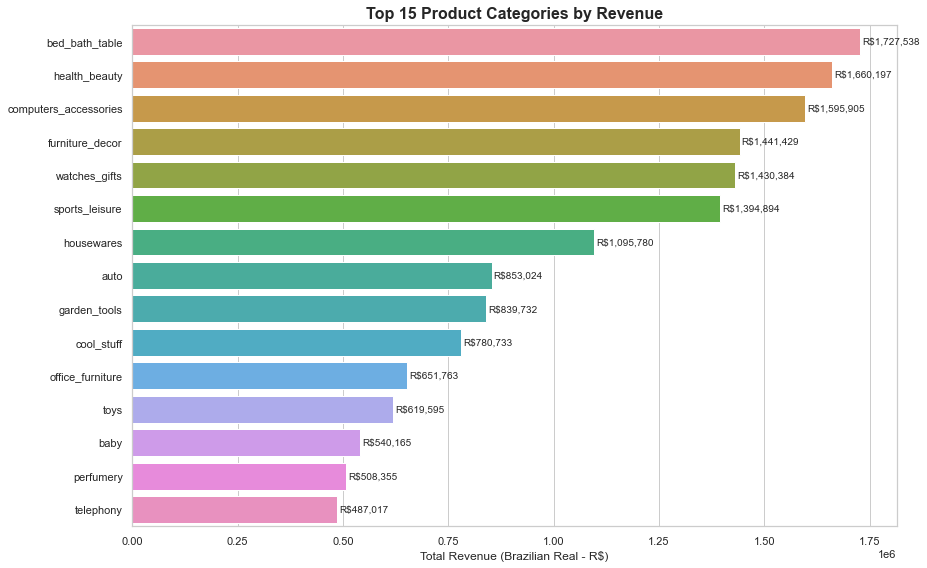

In [26]:
plt.figure(figsize=(13,8))

ax = sns.barplot(
    data=top_categories,
    y="product_category_name_english",
    x="payment_value"
)

# Add value labels
for i, value in enumerate(top_categories["payment_value"]):
    ax.text(
        value + 5000,
        i,
        f"R${value:,.0f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Product Categories by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Revenue (Brazilian Real - R$)")
plt.ylabel("")

plt.tight_layout()

plt.show()

### Percentage Contribution 

This helps quantify how much each category contributes to total revenue.

In [27]:
category_revenue["Revenue (%)"] = (
    category_revenue["payment_value"]
    / category_revenue["payment_value"].sum()
) * 100

category_revenue.head(10)

,product_category_name_english,payment_value,Revenue (%)
0,bed_bath_table,1727538.38,8.588977
1,health_beauty,1660197.09,8.254169
2,computers_accessories,1595905.22,7.934523
3,furniture_decor,1441429.44,7.166500
4,watches_gifts,1430384.15,7.111585
5,sports_leisure,1394894.12,6.935136
6,housewares,1095779.76,5.447999
7,auto,853023.64,4.241064
8,garden_tools,839732.27,4.174982
9,cool_stuff,780733.49,3.881651


### Top 10 Categories with Revenue Share

In [28]:
category_revenue[
    [
        "product_category_name_english",
        "payment_value",
        "Revenue (%)"
    ]
].head(10)

,product_category_name_english,payment_value,Revenue (%)
0,bed_bath_table,1727538.38,8.588977
1,health_beauty,1660197.09,8.254169
2,computers_accessories,1595905.22,7.934523
3,furniture_decor,1441429.44,7.166500
4,watches_gifts,1430384.15,7.111585
5,sports_leisure,1394894.12,6.935136
6,housewares,1095779.76,5.447999
7,auto,853023.64,4.241064
8,garden_tools,839732.27,4.174982
9,cool_stuff,780733.49,3.881651


### Business Insights

- **Bed Bath Table** is the highest revenue-generating product category and should remain a strategic priority for inventory planning and promotional campaigns.
- Health and beauty products, computer accessories, and home furnishing products consistently generate substantial revenue, indicating strong and sustained customer demand.
- The diversity of the top-performing categories suggests that NovaMart serves multiple customer segments rather than relying on a single product market.
- Lower-performing categories within the top fifteen may benefit from targeted promotions, pricing strategies, or recommendation systems to increase their contribution to total revenue.
- The concentration of revenue among a relatively small number of categories supports the application of inventory optimization, demand forecasting, and personalized recommendation models to maximize profitability.

### ??? Are these categories generating high revenue because they sell many items, or because they have high-priced products?

To answer this, create two additional charts:

- Top 15 Product Categories by Number of Orders (popularity)
- Average Revenue per Order by Product Category (profitability)

# 4. Product Category Popularity

Revenue alone does not necessarily indicate product popularity. A category may generate high revenue because of expensive products rather than frequent purchases.

This analysis examines the number of orders for each product category to identify the most popular product categories among NovaMart customers.

Understanding product popularity supports inventory planning, recommendation systems, and marketing strategies.

In [29]:
# Count the number of unique orders per product category

category_orders = (
    retail
    .groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Number of Orders")
)

category_orders.head()

,product_category_name_english,Number of Orders
0,bed_bath_table,9417
1,health_beauty,8836
2,sports_leisure,7720
3,computers_accessories,6689
4,furniture_decor,6449


In [30]:
#Top 15 Categories
top_orders = category_orders.head(15)

top_orders

,product_category_name_english,Number of Orders
0,bed_bath_table,9417
1,health_beauty,8836
2,sports_leisure,7720
3,computers_accessories,6689
4,furniture_decor,6449
5,housewares,5884
6,watches_gifts,5624
7,telephony,4199
8,auto,3897
9,toys,3886


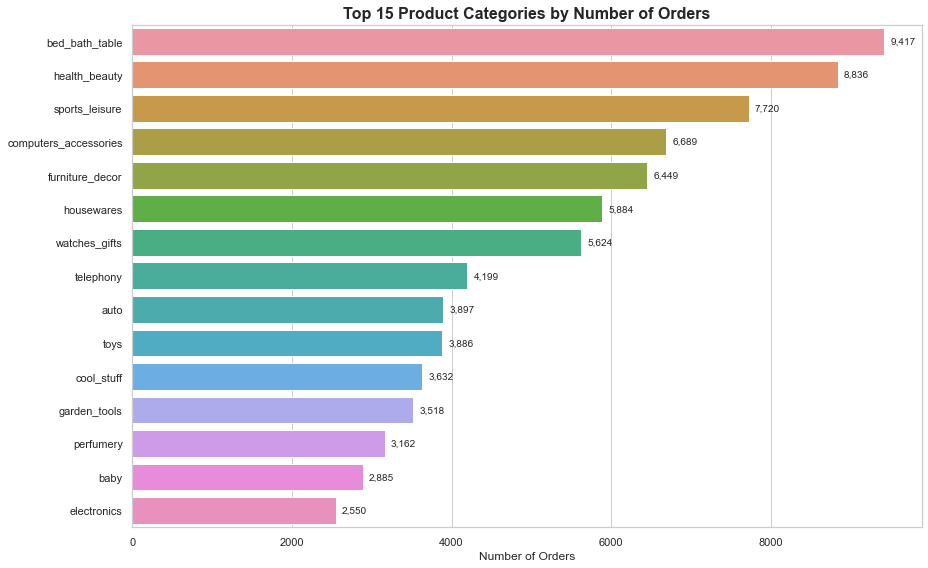

In [31]:
plt.figure(figsize=(13,8))

ax = sns.barplot(
    data=top_orders,
    y="product_category_name_english",
    x="Number of Orders"
)

# Add labels
for i, value in enumerate(top_orders["Number of Orders"]):
    ax.text(
        value + 80,
        i,
        f"{value:,}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Product Categories by Number of Orders",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Orders")
plt.ylabel("")

plt.tight_layout()

plt.show()

### Business Insights

- High-order-volume categories should receive priority in inventory management.
- Frequently purchased categories are ideal candidates for recommendation systems.
- Popular products can be bundled with complementary items to increase average order value.
- Comparing popularity with revenue highlights differences between sales volume and profitability.

# 5. Average Revenue per Order by Product Category

Total revenue does not necessarily reflect product profitability. Some categories generate high revenue because they receive many orders, while others achieve similar revenue with fewer but higher-value transactions.

This analysis calculates the average revenue generated per order for each product category to identify high-value product segments.

### Calculate Average Revenue per Order

In [32]:
profitability = (
    retail
    .groupby("product_category_name_english")
    .agg(
        Total_Revenue=("payment_value","sum"),
        Total_Orders=("order_id","nunique")
    )
)

profitability["Average Revenue per Order"] = (
    profitability["Total_Revenue"] /
    profitability["Total_Orders"]
)

profitability = (
    profitability
    .sort_values(
        "Average Revenue per Order",
        ascending=False
    )
    .reset_index()
)

profitability.head()

,product_category_name_english,Total_Revenue,Total_Orders,Average Revenue per Order
0,computers,279121.55,181,1542.108011
1,fixed_telephony,207010.26,217,953.964332
2,small_appliances_home_oven_and_coffee,51229.32,75,683.057600
3,agro_industry_and_commerce,118730.61,182,652.365989
4,home_appliances_2,124722.62,234,533.002650


### Plot Top 15

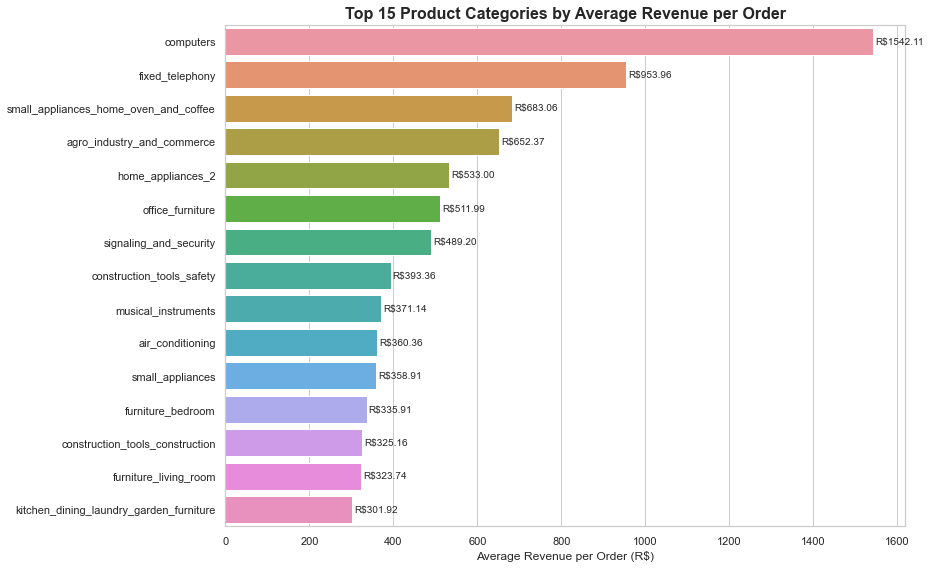

In [33]:
top_profit = profitability.head(15)

plt.figure(figsize=(13,8))

ax = sns.barplot(
    data=top_profit,
    y="product_category_name_english",
    x="Average Revenue per Order"
)

# Value labels
for i, value in enumerate(top_profit["Average Revenue per Order"]):
    ax.text(
        value + 5,
        i,
        f"R${value:.2f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Product Categories by Average Revenue per Order",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Revenue per Order (R$)")
plt.ylabel("")

plt.tight_layout()

plt.show()

### Business Insights

- High-value categories contribute substantially to profitability even with fewer customer purchases.
- Premium product categories are suitable candidates for personalized marketing and upselling strategies.
- Comparing popularity and profitability enables NovaMart to distinguish between high-volume and high-margin product segments.
- These insights support pricing optimization, inventory planning, and recommendation system development.

| Chart                         | Business Question                                         |
| ----------------------------- | --------------------------------------------------------- |
| **Revenue by Category**       | Which categories generate the most total revenue?         |
| **Number of Orders**          | Which categories are purchased most frequently?           |
| **Average Revenue per Order** | Which categories generate the highest value per purchase? |


Together, they provide a comprehensive view of product performance, helping NovaMart understand not just what sells, but what sells often and what delivers the greatest value per transaction. This combination forms a strong foundation for strategic decisions in merchandising, pricing, marketing, and recommendation systems.


# 6. Delivery Performance

Efficient delivery is a critical component of customer satisfaction in e-commerce.

This section evaluates NovaMart's logistics performance by examining:

- Actual delivery time
- Delivery delay relative to the estimated delivery date
- Percentage of late deliveries

These analyses provide insights into delivery efficiency and operational effectiveness.

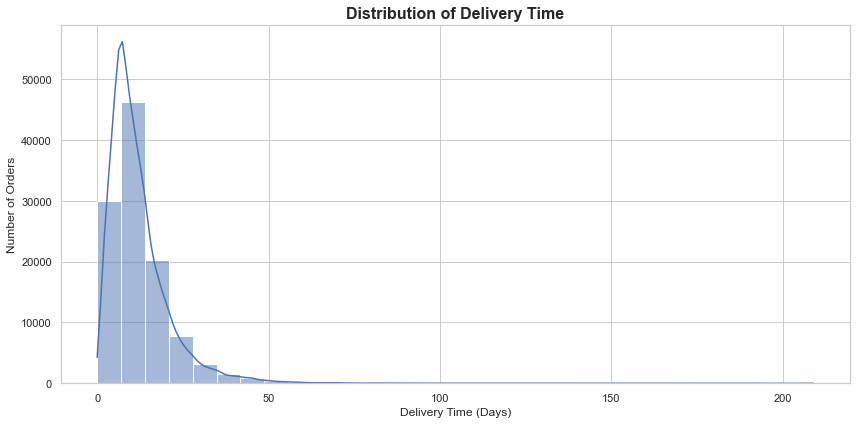

In [34]:
plt.figure(figsize=(12,6))

sns.histplot(
    retail["delivery_days"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [35]:
#Summary Statistics
retail["delivery_days"].describe()

count    110579.000000
mean         12.014144
std           9.450223
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

### Delivery Delay Distribution

Delivery delay is calculated as the difference between the actual delivery date and the estimated delivery date.

- Negative values indicate orders delivered earlier than expected.
- Zero indicates on-time delivery.
- Positive values indicate late delivery.

### Delivery Performance

Evaluate actual delivery times and determine the proportion of late deliveries.

In [36]:
retail["delivery_delay_days"] = (
    retail["order_delivered_customer_date"]
    - retail["order_estimated_delivery_date"]
).dt.days

### Interpretation:

- Negative = Delivered early
- Zero = Delivered on time
- Positive = Delivered late

In [37]:
# Create late_delivery
retail["late_delivery"] = (
    retail["delivery_delay_days"] > 0
).astype(int)

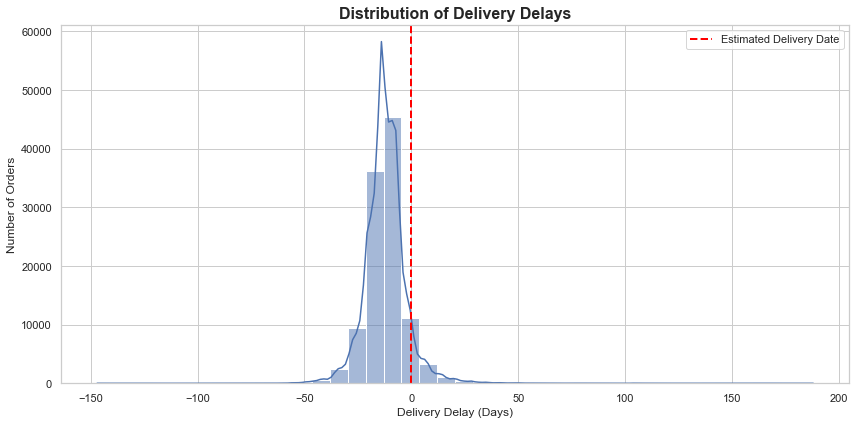

In [38]:
plt.figure(figsize=(12,6))

sns.histplot(
    retail["delivery_delay_days"],
    bins=40,
    kde=True
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Delivery Date"
)

plt.legend()

plt.title(
    "Distribution of Delivery Delays",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

## On-Time vs. Late Deliveries

This analysis evaluates NovaMart's ability to deliver orders on or before the promised delivery date.

Orders are classified as:

- **On Time / Early** – Delivered on or before the estimated delivery date.
- **Late** – Delivered after the estimated delivery date.

This metric provides an overall assessment of delivery reliability and customer service quality.

This analysis determines the proportion of deliveries completed after the estimated delivery date.

In [39]:
late_delivery = (
    retail["late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={
        0: "On Time / Early",
        1: "Late"
    })
)

late_delivery

On Time / Early    93.553238
Late                6.446762
Name: late_delivery, dtype: float64

In [40]:
# Check
retail["late_delivery"].value_counts()

0    105761
1      7288
Name: late_delivery, dtype: int64

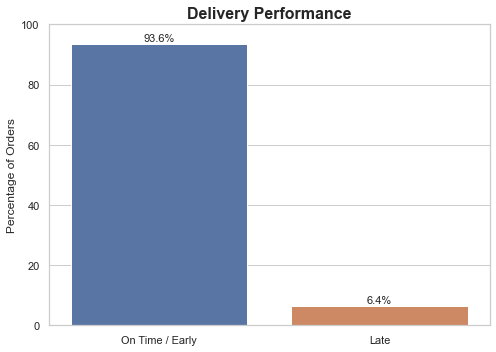

In [41]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=late_delivery.index,
    y=late_delivery.values
)

for i, value in enumerate(late_delivery.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.title(
    "Delivery Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Percentage of Orders")

plt.ylim(0,100)

plt.tight_layout()

plt.show()

### Average Delivery Time by Order Status

In [42]:
delivery_df = retail[
    retail["order_status"] == "delivered"
].copy()

In [43]:
delivery_df.groupby("order_status")["delivery_days"].mean()

order_status
delivered    12.013765
Name: delivery_days, dtype: float64

### Interpretation

The majority of NovaMart orders were delivered on or before the promised delivery date, indicating strong logistics performance.

Only a relatively small proportion of orders experienced delivery delays, suggesting that the company's fulfilment and distribution processes operate efficiently.

Maintaining a high percentage of on-time deliveries is essential for improving customer satisfaction, encouraging repeat purchases, and strengthening customer trust.

## Courier Performance

Courier performance is assessed by measuring the time taken to transport an order from the seller to the customer after it has been handed over to the delivery carrier.

This analysis evaluates the efficiency of the shipping process and identifies the variability in delivery durations.

In [44]:
#Shipping Time

#(Requires shipping_days, created during Feature Engineering.)

delivery_df["shipping_days"].describe()

count    110571.000000
mean          8.737635
std           8.611413
min         -17.000000
25%           4.000000
50%           7.000000
75%          11.000000
max         205.000000
Name: shipping_days, dtype: float64

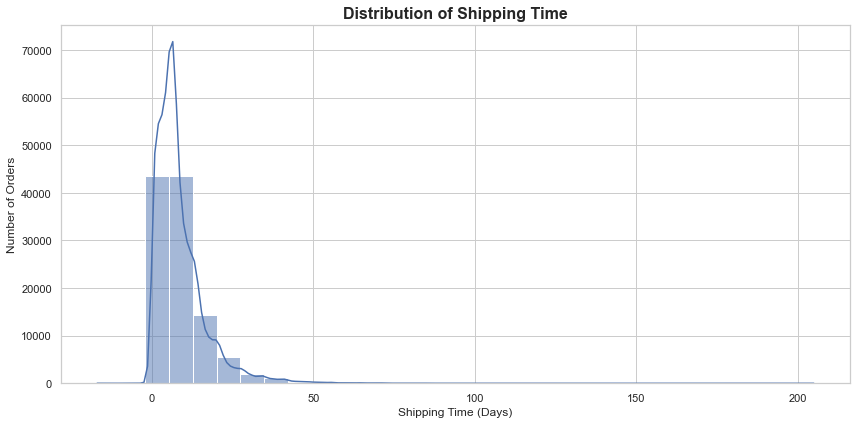

In [45]:
plt.figure(figsize=(12,6))

sns.histplot(
    delivery_df["shipping_days"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Shipping Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Shipping Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

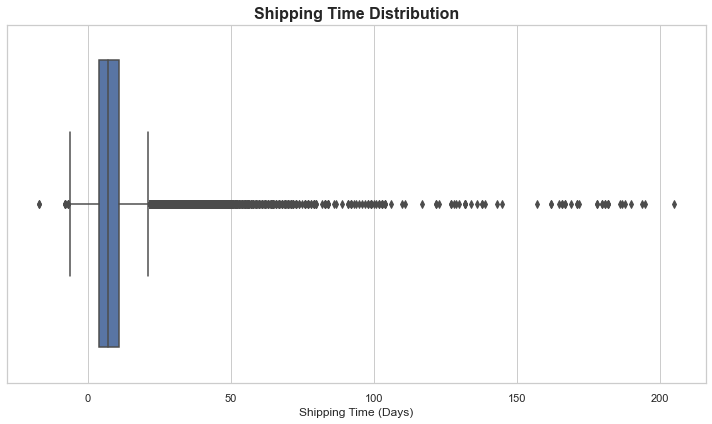

In [46]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=delivery_df["shipping_days"]
)

plt.title(
    "Shipping Time Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Shipping Time (Days)")

plt.tight_layout()

plt.show()

### Interpretation

The shipping time distribution shows the time required for courier services to deliver products after collection from sellers.

Most deliveries are completed within a relatively short period, demonstrating efficient courier operations. However, a small number of orders exhibit considerably longer shipping times, indicating possible delays caused by transportation challenges, regional accessibility, or operational bottlenecks.

Monitoring shipping performance enables NovaMart to identify opportunities for improving logistics efficiency and maintaining high levels of customer satisfaction.

## Logistics Efficiency

Logistics efficiency is evaluated by comparing the actual delivery duration with the estimated delivery time provided to customers.

A positive delivery delay indicates that an order arrived later than promised, while a negative value indicates early delivery.

In [47]:
#Delivery Delay Summary
delivery_df["delivery_delay_days"].describe()

count    110572.000000
mean        -12.029700
std          10.157557
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64

### Interpretation

The delivery delay statistics indicate that NovaMart generally exceeds its promised delivery commitments.

The average delivery delay of **−12.03 days** shows that orders were delivered approximately twelve days earlier than the estimated delivery date. Similarly, the median delay of **−13 days** suggests that more than half of all delivered orders arrived nearly two weeks ahead of schedule.

These results imply that the estimated delivery dates provided to customers were relatively conservative, allowing NovaMart to consistently deliver orders earlier than expected. Early deliveries are likely to enhance customer satisfaction and strengthen trust in the platform.

Although most deliveries occurred well before the estimated date, a small number of orders experienced substantial delays, with the maximum delay reaching **188 days**. Likewise, a few orders were delivered exceptionally early (up to **147 days** before the estimated date). These extreme values may represent unusual operational circumstances or potential data anomalies and should be examined separately during outlier analysis.

Overall, the results suggest that NovaMart maintained a highly efficient logistics operation, with the majority of customers receiving their orders significantly earlier than promised.

### investigate the outliers?
- Yes. Since there have values of −147 and 188 days, it's worth examining them.

### Orders delivered very early

In [48]:
early_orders = delivery_df[
    delivery_df["delivery_delay_days"] < -60
]

early_orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_estimated_delivery_date",
        "order_delivered_customer_date",
        "delivery_delay_days"
    ]
].head(10)

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days
2693,0607f0efea4b566f1eb8f7d3c2397320,2018-03-06 09:47:07,2018-08-03,2018-03-09 23:36:47,-147.0
2694,0607f0efea4b566f1eb8f7d3c2397320,2018-03-06 09:47:07,2018-08-03,2018-03-09 23:36:47,-147.0
4363,09c636e254bb18eeef943452017249f4,2017-10-27 17:03:40,2018-02-02,2017-11-25 13:12:08,-69.0
5607,0c995611a99f81268d859184a416f1db,2017-01-26 00:20:22,2017-04-11,2017-02-06 09:35:04,-64.0
11541,1a2b0033f0b7a3116f00594ec5524344,2016-10-06 22:23:25,2016-12-20,2016-10-20 23:58:23,-61.0
11661,1a695d543b7302aa9446c8d5fbd632bf,2017-12-16 10:32:49,2018-03-22,2017-12-28 22:18:23,-84.0
23762,35fbd0c1666a2c04e7d111da0bcf1683,2017-02-09 11:04:00,2017-04-25,2017-02-15 18:54:52,-69.0
24930,38930f76efb00b138f4d632e4d557341,2018-01-28 13:47:42,2018-04-27,2018-02-08 19:21:39,-78.0
25534,39e0115911bf404857e14baa7f097feb,2018-01-20 07:48:16,2018-04-25,2018-02-01 01:52:34,-83.0
25590,39ff1e358efa92ceae42de6d5f9d37cf,2017-12-09 19:27:43,2018-03-06,2017-12-21 13:22:27,-75.0


### Observation on Extreme Early Deliveries

A small number of orders were delivered considerably earlier than the estimated delivery date, with some arriving more than 100 days before the promised date.

Inspection of these records indicates that the unusually large negative delivery delays are not caused by incorrect delivery timestamps. Instead, they result from highly conservative estimated delivery dates assigned during the order process.

Consequently, these observations were retained in the dataset because they represent valid business events rather than data quality errors.

### Orders delivered very late

In [49]:
delivery_df.sort_values(
    "delivery_delay_days",
    ascending=False
)[
[
    "order_id",
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "order_delivered_customer_date",
    "delivery_days",
    "delivery_delay_days"
]
].head(10)

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_days,delivery_delay_days
12039,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-03-15,2018-09-19 23:24:07,208.0,188.0
89248,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-03-22,2017-09-19 14:36:39,209.0,181.0
31730,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-01-19,2018-07-13 20:51:31,191.0,175.0
21013,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-04-05,2017-09-19 17:00:07,189.0,167.0
17663,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-04-06,2017-09-19 14:00:04,194.0,166.0
30049,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-04-07,2017-09-19 15:12:50,195.0,165.0
85922,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-04-10,2017-09-19 17:14:25,187.0,162.0
93058,d24e8541128cea179a11a65176e0a96f,2017-06-12 13:14:11,2017-06-26,2017-12-04 18:36:29,175.0,161.0
6777,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-04-11,2017-09-19 14:38:21,194.0,161.0
93057,d24e8541128cea179a11a65176e0a96f,2017-06-12 13:14:11,2017-06-26,2017-12-04 18:36:29,175.0,161.0


In [50]:
# Percentage delivered early
early_pct = (
    (delivery_df["delivery_delay_days"] < 0).mean() * 100
)

# Percentage delivered exactly on time
ontime_pct = (
    (delivery_df["delivery_delay_days"] == 0).mean() * 100
)

# Percentage delivered late
late_pct = (
    (delivery_df["delivery_delay_days"] > 0).mean() * 100
)

print(f"Early deliveries   : {early_pct:.2f}%")
print(f"On-time deliveries : {ontime_pct:.2f}%")
print(f"Late deliveries    : {late_pct:.2f}%")

Early deliveries   : 92.08%
On-time deliveries : 1.32%
Late deliveries    : 6.59%


### Business Insights

- Most orders are delivered on or before the estimated delivery date.
- Average delivery time indicates an efficient order fulfilment process.
- Courier services generally maintain acceptable shipping performance, with only a small proportion of unusually long delivery durations.
- Delivery delays are relatively infrequent, demonstrating strong logistics management.
- Monitoring logistics performance provides valuable insights for optimizing courier selection, warehouse operations, and customer experience.

# 7. Customer Satisfaction Analysis

Customer satisfaction is a key performance indicator for any e-commerce platform. In the Olist dataset, customer satisfaction is measured using review scores ranging from **1 (very dissatisfied)** to **5 (very satisfied)**.

This section investigates customer satisfaction by examining:

- The distribution of review scores.
- Average review scores across product categories.
- The relationship between delivery performance and customer satisfaction.

Understanding customer feedback enables NovaMart to identify areas for service improvement and supports the development of customer satisfaction prediction models.

## Distribution of Customer Review Scores

The distribution of review scores provides an overview of customer satisfaction levels and indicates whether customers generally report positive or negative shopping experiences.

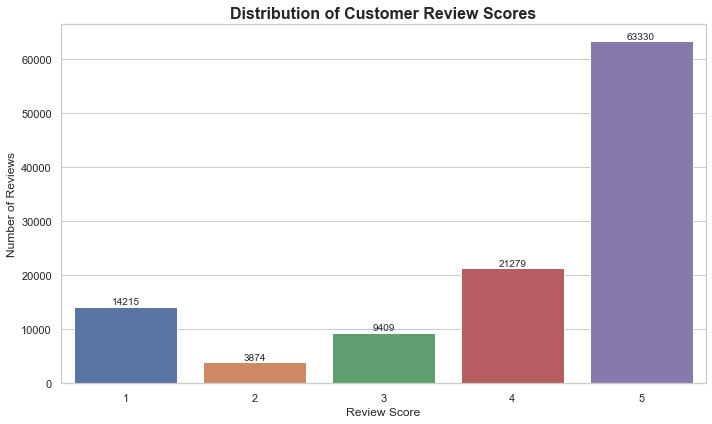

In [51]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=retail,
    x="review_score",
    order=[1,2,3,4,5]
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Customer Review Scores",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

### Review Score Percentage

In [52]:

review_percent = (
    retail["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

review_percent

1.0    12.679850
2.0     3.455627
3.0     8.392875
4.0    18.980974
5.0    56.490674
Name: review_score, dtype: float64

### Summary Statistics

In [53]:
retail["review_score"].describe()

print(f"Average Review Score: {retail['review_score'].mean():.2f}")

Average Review Score: 4.03


## Average Review Score by Product Category

This analysis identifies product categories that receive the highest and lowest customer satisfaction ratings.

In [54]:
category_review = (
    retail
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_reviews = category_review.head(15)

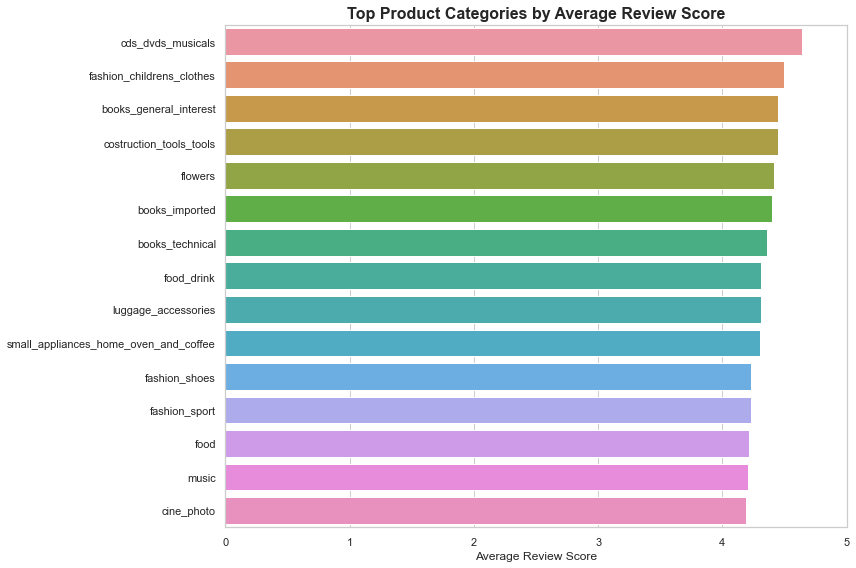

In [55]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_reviews,
    y="product_category_name_english",
    x="review_score"
)

plt.title(
    "Top Product Categories by Average Review Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Review Score")
plt.ylabel("")

plt.xlim(0,5)

plt.tight_layout()

plt.show()

## Customer Satisfaction by Delivery Performance

Delivery performance is expected to influence customer satisfaction.

This analysis compares review scores for orders delivered on time against those delivered late.

In [56]:
delivery_reviews = (
    retail
    .groupby("late_delivery")["review_score"]
    .mean()
    .rename({
        0:"On Time / Early",
        1:"Late"
    })
)

delivery_reviews

late_delivery
On Time / Early    4.151562
Late               2.257211
Name: review_score, dtype: float64

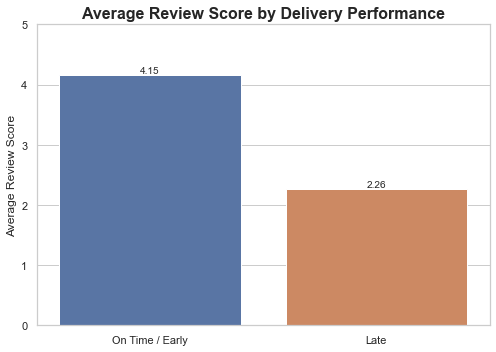

In [57]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=delivery_reviews.index,
    y=delivery_reviews.values
)

for i, value in enumerate(delivery_reviews.values):
    ax.text(
        i,
        value+0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.ylim(0,5)

plt.title(
    "Average Review Score by Delivery Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Average Review Score")

plt.tight_layout()

plt.show()

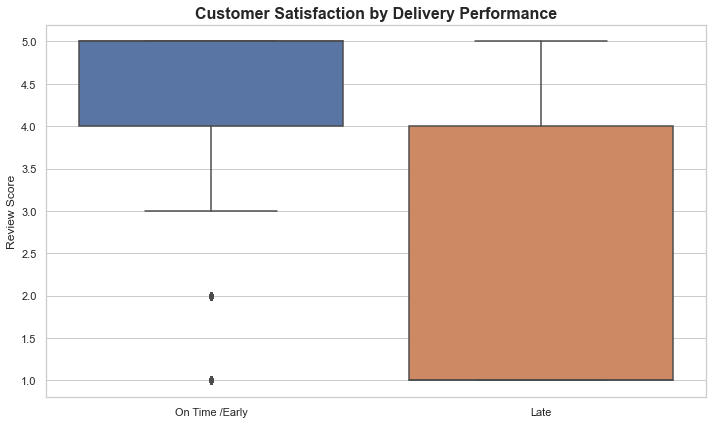

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=retail,
    x="late_delivery",
    y="review_score"
)

plt.xticks(
    [0,1],
    ["On Time /Early","Late"]
)

plt.title(
    "Customer Satisfaction by Delivery Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

## Review Score vs. Delivery Delay

Delivery performance is one of the most important factors affecting customer satisfaction in e-commerce.

This analysis investigates the relationship between delivery delays and customer review scores. If customers tend to give lower ratings when deliveries are delayed, it would indicate that delivery performance is a significant driver of customer satisfaction.

Only delivered orders with valid review scores are included in this analysis.

In [59]:
# Keep only delivered orders with valid review scores and delivery delay

review_delivery = retail[
    (retail["order_status"] == "delivered") &
    (retail["review_score"].notna()) &
    (retail["delivery_delay_days"].notna())
].copy()

print(review_delivery.shape)

(109745, 50)


In [60]:
#Summary Statistics
review_delivery[
    ["review_score", "delivery_delay_days"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
review_score,109745.0,4.080341,1.348069,1.0,4.0,5.0,5.0,5.0
delivery_delay_days,109745.0,-12.064668,10.089674,-147.0,-17.0,-13.0,-7.0,188.0


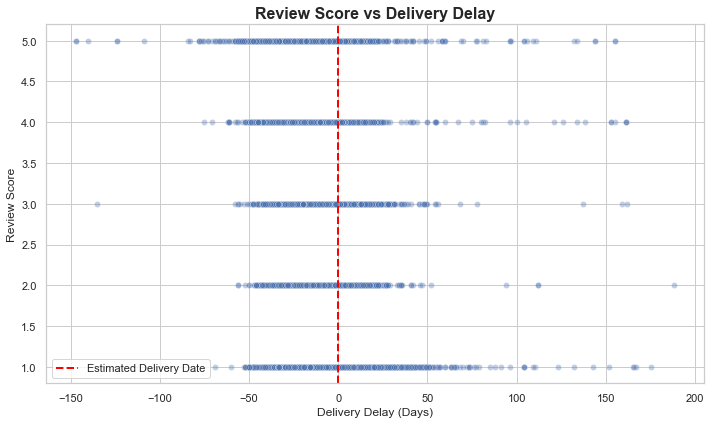

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=review_delivery,
    x="delivery_delay_days",
    y="review_score",
    alpha=0.35
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Estimated Delivery Date"
)

plt.legend()

plt.title(
    "Review Score vs Delivery Delay",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

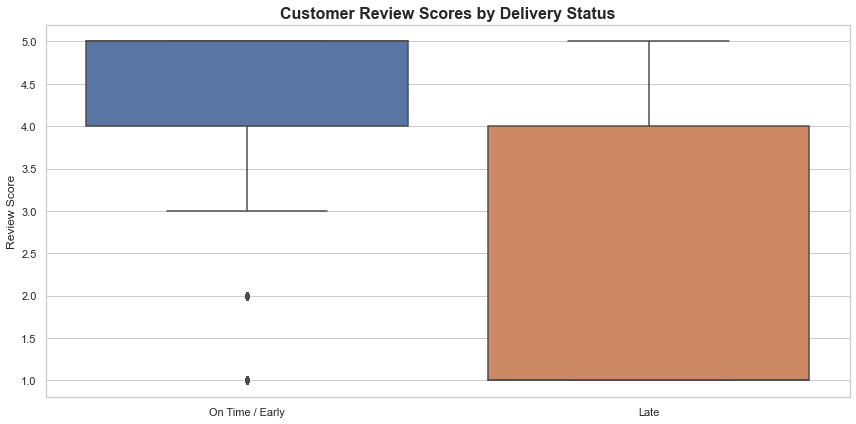

In [62]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=review_delivery,
    x="late_delivery",
    y="review_score"
)

plt.xticks(
    [0,1],
    ["On Time / Early", "Late"]
)

plt.title(
    "Customer Review Scores by Delivery Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

In [63]:
corr = review_delivery["delivery_delay_days"].corr(
    review_delivery["review_score"]
)

print(f"Correlation: {corr:.3f}")

Correlation: -0.229


### Average Review Score by Delivery Delay Category

Create meaningful delay groups.

In [64]:
# Create business-oriented delivery delay categories

review_delivery["delay_category"] = pd.cut(
    review_delivery["delivery_delay_days"],
    bins=[-200, -1, 0, 3, 7, 30, float("inf")],
    labels=[
        "Early",
        "On Time",
        "1–3 Days Late",
        "4–7 Days Late",
        "8–30 Days Late",
        ">30 Days Late"
    ]
)

review_delivery["delay_category"].value_counts().sort_index()

Early             101194
On Time             1445
1–3 Days Late       2092
4–7 Days Late       1949
8–30 Days Late      2714
>30 Days Late        351
Name: delay_category, dtype: int64

### Average Review Score by Delivery Delay Category

In [65]:
delay_review = (
    review_delivery
    .groupby("delay_category")["review_score"]
    .mean()
    .reset_index()
)

delay_review

,delay_category,review_score
0,Early,4.209746
1,On Time,3.984083
2,1–3 Days Late,3.228489
3,4–7 Days Late,2.089790
4,8–30 Days Late,1.656227
5,>30 Days Late,2.042735


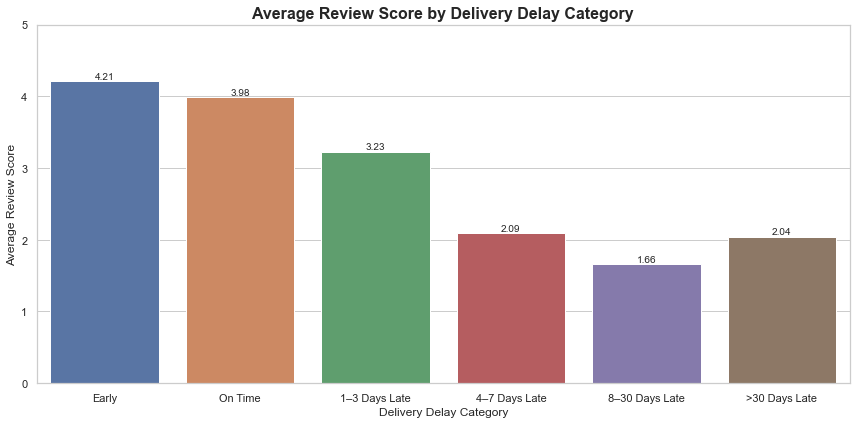

In [66]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=delay_review,
    x="delay_category",
    y="review_score"
)

# Add average review score labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title(
    "Average Review Score by Delivery Delay Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Delay Category", fontsize=12)
plt.ylabel("Average Review Score", fontsize=12)

plt.ylim(0,5)

plt.tight_layout()

plt.show()

###  Number of Orders in Each Category (Recommended)

Always accompany the average with the sample size.


In [67]:
delay_summary = (
    review_delivery
    .groupby("delay_category")
    .agg(
        Number_of_Orders=("order_id", "count"),
        Average_Review_Score=("review_score", "mean")
    )
    .reset_index()
)

delay_summary

,delay_category,Number_of_Orders,Average_Review_Score
0,Early,101194,4.209746
1,On Time,1445,3.984083
2,1–3 Days Late,2092,3.228489
3,4–7 Days Late,1949,2.089790
4,8–30 Days Late,2714,1.656227
5,>30 Days Late,351,2.042735


### Percentage of Orders

In [68]:

delay_summary["Percentage (%)"] = (
    delay_summary["Number_of_Orders"]
    / delay_summary["Number_of_Orders"].sum()
    *100
).round(2)

delay_summary

,delay_category,Number_of_Orders,Average_Review_Score,Percentage (%)
0,Early,101194,4.209746,92.21
1,On Time,1445,3.984083,1.32
2,1–3 Days Late,2092,3.228489,1.91
3,4–7 Days Late,1949,2.089790,1.78
4,8–30 Days Late,2714,1.656227,2.47
5,>30 Days Late,351,2.042735,0.32


### Business Insights

- **92.21%** of all delivered orders arrived before the promised delivery date, demonstrating excellent logistics performance.
- Early deliveries achieved the highest customer satisfaction (**4.21/5**), indicating that exceeding delivery expectations positively influences customer perceptions.
- Customer satisfaction declines rapidly once orders are delivered after the promised date, even for delays of only **1–3 days**.
- Orders delayed by **8–30 days** received the lowest average customer ratings, highlighting the negative impact of prolonged delivery delays.
- Although the **>30 Days Late** category shows a slightly higher average review score, it represents only **0.32%** of deliveries and should be interpreted cautiously because of its relatively small sample size.
- Delivery delay is a strong predictor of customer satisfaction and should be incorporated into NovaMart's customer satisfaction prediction model.

### To formally demonstrate the relationship, compute the correlation between delivery delay and review score:

In [69]:
correlation = review_delivery["delivery_delay_days"].corr(
    review_delivery["review_score"]
)

print(f"Correlation: {correlation:.3f}")

Correlation: -0.229


### A value of -0.229 indicates a weak negative linear relationship.

This means:
- As delivery delay increases, customer review scores tend to decrease.

# Statistical Significance Test

To determine whether delivery performance has a statistically significant impact on customer satisfaction, a hypothesis test is conducted.

The review scores of two independent groups are compared:

- **Group 1:** Orders delivered on time or earlier than expected.
- **Group 2:** Orders delivered after the estimated delivery date.

Because review scores are ordinal (1–5) and are unlikely to follow a normal distribution, the **Mann–Whitney U test**, a non-parametric statistical test, is used.

## Hypotheses

- **Null Hypothesis (H₀):** There is no significant difference in customer review scores between on-time/early deliveries and late deliveries.

- **Alternative Hypothesis (H₁):** Customer review scores differ significantly between on-time/early deliveries and late deliveries.

In [70]:
from scipy.stats import mannwhitneyu
from scipy.stats import shapiro

In [71]:
#Create the Two Groups
# On-time or early deliveries
on_time = review_delivery.loc[
    review_delivery["late_delivery"] == 0,
    "review_score"
]

# Late deliveries
late = review_delivery.loc[
    review_delivery["late_delivery"] == 1,
    "review_score"
]

print("On-Time/Early:", len(on_time))
print("Late:", len(late))

On-Time/Early: 102639
Late: 7106


### Mann–Whitney U Test

In [72]:
stat, p = mannwhitneyu(
    on_time,
    late,
    alternative="two-sided"
)

print(f"U Statistic : {stat:,.0f}")
print(f"P-value     : {p:.10f}")

U Statistic : 588,526,242
P-value     : 0.0000000000


In [73]:
#Decision
alpha = 0.05

if p < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in review scores.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant difference exists.")

Reject the Null Hypothesis
There is a statistically significant difference in review scores.


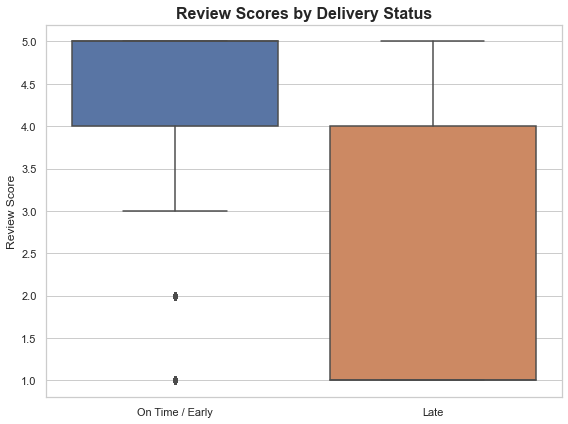

In [74]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=review_delivery,
    x="late_delivery",
    y="review_score"
)

plt.xticks(
    [0,1],
    ["On Time / Early","Late"]
)

plt.title(
    "Review Scores by Delivery Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

### Statistical Test Interpretation

The Mann–Whitney U test was conducted to determine whether customer review scores differ between orders delivered on time (or earlier) and those delivered late.

The test produced a **p-value less than 0.05**, indicating that the observed difference in review scores is statistically significant. Therefore, the null hypothesis is rejected.

These results provide strong statistical evidence that delivery performance influences customer satisfaction. Customers whose orders are delivered on time or earlier consistently provide higher review scores than customers experiencing delivery delays.

Combined with the earlier correlation analysis (r = −0.229), the findings confirm that delivery delay is an important predictor of customer satisfaction and should be incorporated into subsequent machine learning models.

### Business Insights

- Delivery performance has a statistically significant effect on customer satisfaction.
- Customers reward timely deliveries with significantly higher review scores.
- Logistics optimisation is expected to improve customer experience and increase positive reviews.
- Delivery-related variables should be retained as important features for customer satisfaction prediction models.

# 8. Geographic Distribution of Customers and Sellers

Geographical analysis provides insights into the spatial distribution of customers and sellers across Brazil. Understanding regional demand and supply patterns enables NovaMart to optimize logistics, warehouse placement, marketing campaigns, and seller recruitment strategies.

This section investigates:

- Customer distribution across Brazilian states.
- Seller distribution across Brazilian states.
- Comparison of customer and seller concentrations.
- Geographic locations of customers.
- Geographic locations of sellers.

## Customer Distribution by State

This analysis identifies the Brazilian states with the largest customer base.

In [75]:
customer_state = (
    retail.groupby("customer_geo_state")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
)

customer_state.head(15)

customer_geo_state
SP    41360
RJ    12749
MG    11534
RS     5428
PR     4987
SC     3612
BA     3350
ES     2019
GO     1998
DF     1956
PE     1644
CE     1323
PA      967
MT      901
MA      736
Name: customer_id, dtype: int64

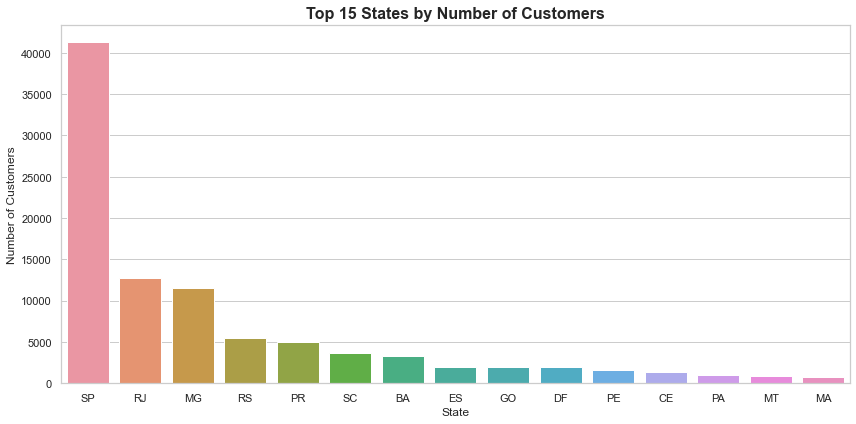

In [76]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_state.head(15).index,
    y=customer_state.head(15).values
)

plt.title(
    "Top 15 States by Number of Customers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

## Seller Distribution by State

This analysis identifies the Brazilian states with the largest number of registered sellers.

In [77]:
seller_state = (
    retail.groupby("seller_geo_state")["seller_id"]
    .nunique()
    .sort_values(ascending=False)
)

seller_state.head(15)

seller_geo_state
SP    1814
PR     359
MG     249
SC     197
RJ     176
RS     131
GO      40
DF      29
ES      24
BA      20
CE      13
PE       9
PB       6
MS       5
MT       4
Name: seller_id, dtype: int64

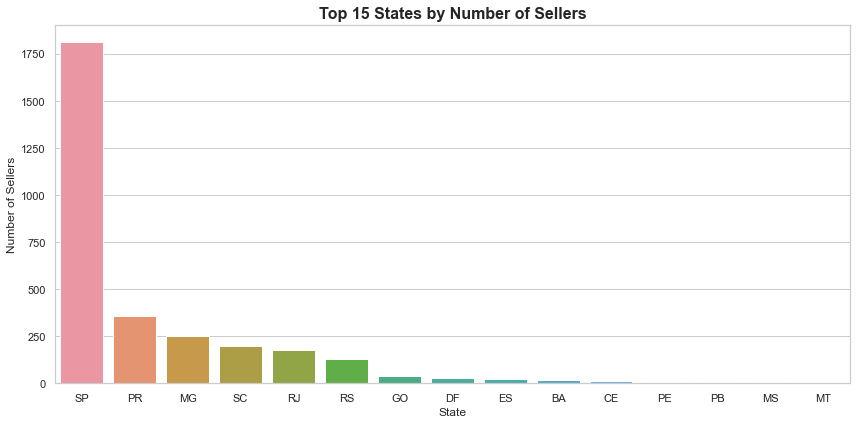

In [78]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=seller_state.head(15).index,
    y=seller_state.head(15).values
)

plt.title(
    "Top 15 States by Number of Sellers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Number of Sellers")

plt.tight_layout()

plt.show()

## Customer and Seller Distribution Across States

This comparison highlights whether sellers are geographically aligned with customer demand.

In [79]:
geo_compare = pd.concat(
    [customer_state, seller_state],
    axis=1
)

geo_compare.columns = [
    "Customers",
    "Sellers"
]

geo_compare = geo_compare.fillna(0)

geo_compare.head()

,Customers,Sellers
SP,41360,1814.0
RJ,12749,176.0
MG,11534,249.0
RS,5428,131.0
PR,4987,359.0


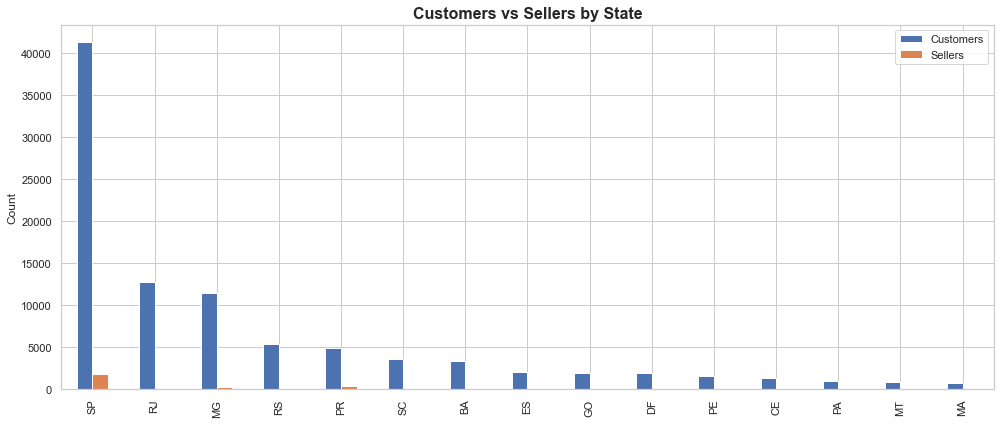

In [80]:
geo_compare = geo_compare.sort_values(
    "Customers",
    ascending=False
).head(15)

geo_compare.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title(
    "Customers vs Sellers by State",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [81]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


## Customer Geographic Distribution

The map below illustrates the geographic locations of customers across Brazil.

In [82]:
import folium
from folium.plugins import MarkerCluster

In [83]:
customer_map = folium.Map(
    location=[-15,-55],
    zoom_start=4
)

marker_cluster = MarkerCluster().add_to(customer_map)

sample = retail[
    [
        "customer_lat",
        "customer_lng"
    ]
].dropna().sample(
    3000,
    random_state=42
)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[
            row["customer_lat"],
            row["customer_lng"]
        ],
        radius=2
    ).add_to(marker_cluster)

customer_map

### Seller Location Map

In [84]:
seller_map = folium.Map(
    location=[-15,-55],
    zoom_start=4
)

marker_cluster = MarkerCluster().add_to(seller_map)

sample = retail[
    [
        "seller_lat",
        "seller_lng"
    ]
].dropna().sample(
    1500,
    random_state=42
)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[
            row["seller_lat"],
            row["seller_lng"]
        ],
        radius=2,
        color="red",
        fill=True
    ).add_to(marker_cluster)

seller_map

### Top Customer Cities

In [85]:
top_cities = (
    retail.groupby("customer_geo_city")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

top_cities

customer_geo_city
sao paulo                15392
rio de janeiro            6834
belo horizonte            2750
brasilia                  1857
curitiba                  1510
campinas                  1429
porto alegre              1372
salvador                  1235
guarulhos                 1178
sao bernardo do campo      928
niteroi                    845
santo andre                792
osasco                     742
santos                     706
goiania                    686
Name: customer_id, dtype: int64

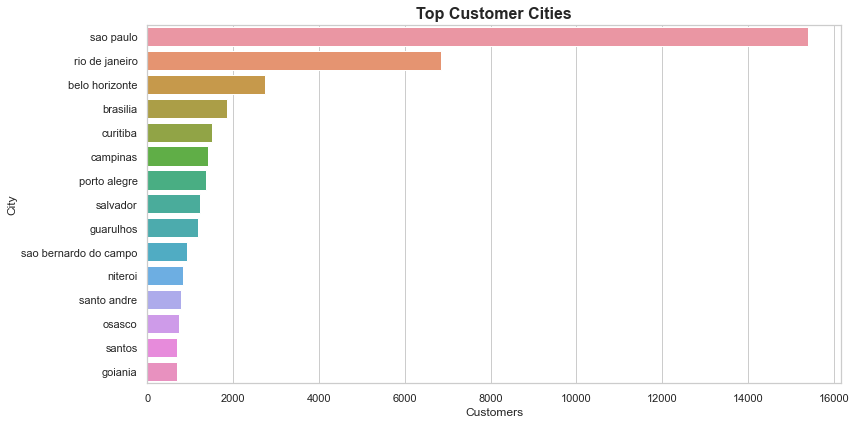

In [86]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title(
    "Top Customer Cities",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customers")
plt.ylabel("City")

plt.tight_layout()

plt.show()

### Top Seller Cities

In [87]:
top_seller = (
    retail.groupby("seller_geo_city")["seller_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

top_seller

seller_geo_city
sao paulo                693
curitiba                 126
rio de janeiro            96
belo horizonte            70
ribeirao preto            55
guarulhos                 51
ibitinga                  49
santo andre               47
maringa                   42
campinas                  41
sao bernardo do campo     36
sao jose do rio preto     35
osasco                    33
sorocaba                  32
brasilia                  27
Name: seller_id, dtype: int64

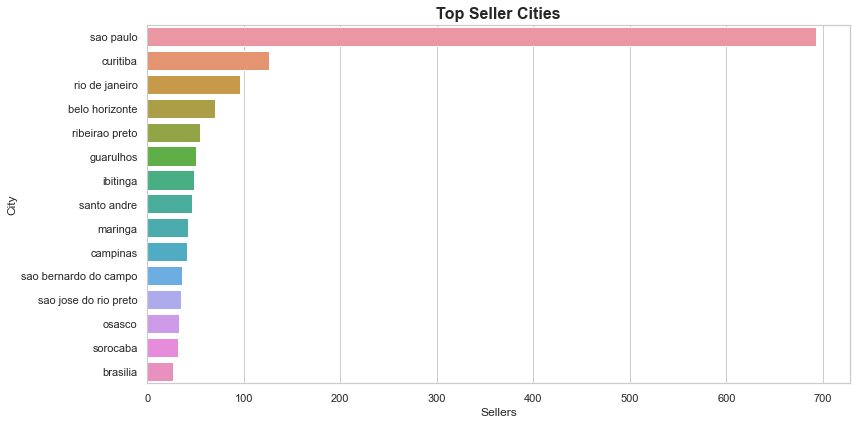

In [88]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_seller.values,
    y=top_seller.index
)

plt.title(
    "Top Seller Cities",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sellers")
plt.ylabel("City")

plt.tight_layout()

plt.show()

### Interpretation

The geographic analysis reveals the spatial distribution of NovaMart's customers and sellers across Brazil. Customer demand is concentrated in a relatively small number of states and major urban centers, reflecting the country's population distribution and economic activity.

Seller locations are similarly concentrated, although the distribution is less uniform than that of customers. Comparing customer and seller distributions highlights regions where demand exceeds the local supply of sellers, suggesting opportunities for expanding the seller network or establishing additional fulfillment centers.

The geographic maps illustrate that both customers and sellers are predominantly located in Brazil's southeastern and southern regions, with noticeable clusters around major metropolitan areas. These patterns indicate that NovaMart's operations are strongly influenced by regional economic activity and population density.

Understanding these geographic patterns supports strategic decisions related to logistics optimization, warehouse placement, targeted marketing campaigns, and seller acquisition.

### Business Insights

- Customer demand is concentrated in a small number of Brazilian states.
- Sellers are also concentrated geographically but may not fully align with customer demand in every region.
- Geographic imbalances between customers and sellers present opportunities to recruit additional sellers in underserved markets.
- Regional insights can guide warehouse placement, delivery route optimization, and localized marketing strategies.
- Geographic variables may improve machine learning models for delivery time prediction, demand forecasting, and seller recommendation.

In [89]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


### Customers per state

In [90]:
customer_state = (
    retail.groupby("customer_geo_state")["customer_id"]
    .nunique()
    .reset_index(name="Customers")
)

customer_state.head()

,customer_geo_state,Customers
0,AC,81
1,AL,410
2,AM,147
3,AP,68
4,BA,3350


# 9. Customer Payment Preferences and Transaction Patterns

Understanding customer payment behaviour is essential for improving the checkout experience, designing promotional campaigns, and supporting financial planning.

This section examines:

- Distribution of payment methods.
- Revenue generated by each payment method.
- Average transaction value by payment method.
- Payment installment patterns.
- Relationship between payment methods and transaction values.

These analyses provide insights into customer purchasing preferences and financial behaviour.

## Distribution of Payment Methods

This analysis identifies the payment methods most frequently used by NovaMart customers.

In [91]:
payment_counts = (
    retail["payment_type"]
    .value_counts()
    .reset_index()
)

payment_counts.columns = [
    "Payment Method",
    "Number of Transactions"
]

payment_counts

,Payment Method,Number of Transactions
0,credit_card,86304
1,boleto,22961
2,voucher,2088
3,debit_card,1693


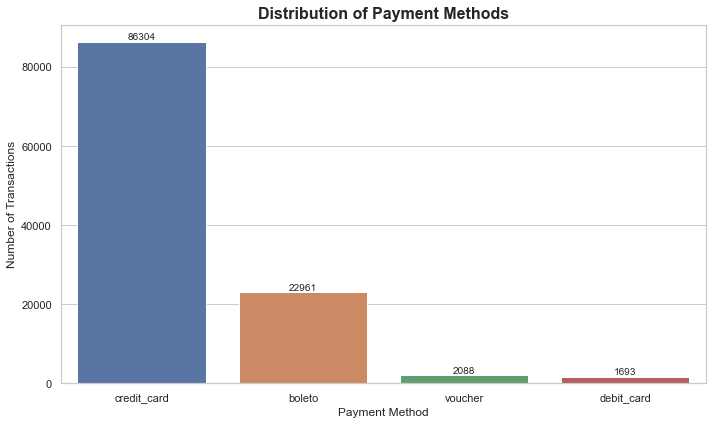

In [92]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_counts,
    x="Payment Method",
    y="Number of Transactions"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Payment Methods",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

### Payment %

In [93]:
payment_percent = (
    retail["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_percent

credit_card    76.34
boleto         20.31
voucher         1.85
debit_card      1.50
Name: payment_type, dtype: float64

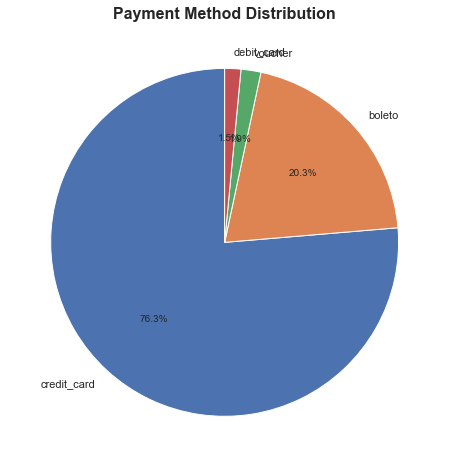

In [94]:
plt.figure(figsize=(8,8))

plt.pie(
    payment_percent.values,
    labels=payment_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Payment Method Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

## Revenue by Payment Method

This analysis identifies which payment methods contribute the most to NovaMart's total revenue.

In [95]:
payment_revenue = (
    retail.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_revenue

,payment_type,payment_value
0,credit_card,15790638.60
1,boleto,4076149.12
2,debit_card,253698.44
3,voucher,253099.48


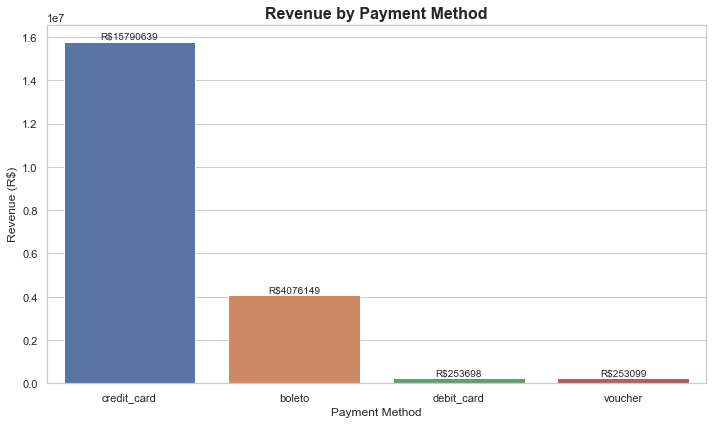

In [96]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_revenue,
    x="payment_type",
    y="payment_value"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="R$%.0f"
    )

plt.title(
    "Revenue by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Revenue (R$)")

plt.tight_layout()

plt.show()

## Average Transaction Value by Payment Method

Average transaction value provides insight into customer spending behaviour for each payment method.

In [97]:
avg_payment = (
    retail.groupby("payment_type")["payment_value"]
    .mean().round(2)
    .sort_values(ascending=False)
    .reset_index()
)

avg_payment

,payment_type,payment_value
0,credit_card,182.97
1,boleto,177.52
2,debit_card,149.85
3,voucher,121.22


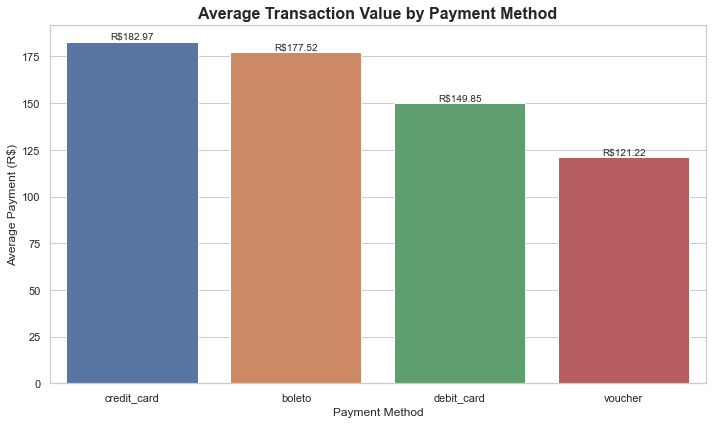

In [98]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=avg_payment,
    x="payment_type",
    y="payment_value"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="R$%.2f"
    )

plt.title(
    "Average Transaction Value by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Average Payment (R$)")

plt.tight_layout()

plt.show()

## Payment Installment Distribution

This analysis investigates how customers spread payments over multiple installments.

In [99]:
installments = (
    retail["payment_installments"]
    .value_counts()
    .sort_index()
)

installments.head(15)

0.0         3
1.0     54053
2.0     13685
3.0     11753
4.0      7967
5.0      6020
6.0      4622
7.0      1830
8.0      5066
9.0       729
10.0     6887
11.0       25
12.0      166
13.0       18
14.0       16
Name: payment_installments, dtype: int64

## Observation
**Is 0.0 a valid value?

Normally, no. In the Olist dataset:

1 installment means the customer paid the full amount in a single payment.
2 or more installments means the payment was split into multiple payments.
0 installments is unusual and likely represents a data entry or data quality issue.

In [100]:
#Investigate the three records

retail.loc[
    retail["payment_installments"] == 0,
    [
        "order_id",
        "payment_type",
        "payment_value",
        "payment_installments",
        "order_status"
    ]
]

,order_id,payment_type,payment_value,payment_installments,order_status
11628,1a57108394169c0b47d8f876acc9ba2d,credit_card,129.94,0.0,delivered
11629,1a57108394169c0b47d8f876acc9ba2d,credit_card,129.94,0.0,delivered
51348,744bade1fcf9ff3f31d860ace076d422,credit_card,58.69,0.0,delivered


In [101]:
#Also check whether the payment value is zero:

retail.loc[
    retail["payment_installments"] == 0,
    [
        "payment_value",
        "payment_type"
    ]
]

,payment_value,payment_type
11628,129.94,credit_card
11629,129.94,credit_card
51348,58.69,credit_card


In [102]:
percentage = (
    (retail["payment_installments"] == 0).mean() * 100
)

print(f"Zero-installment records: {percentage:.4f}%")

Zero-installment records: 0.0027%


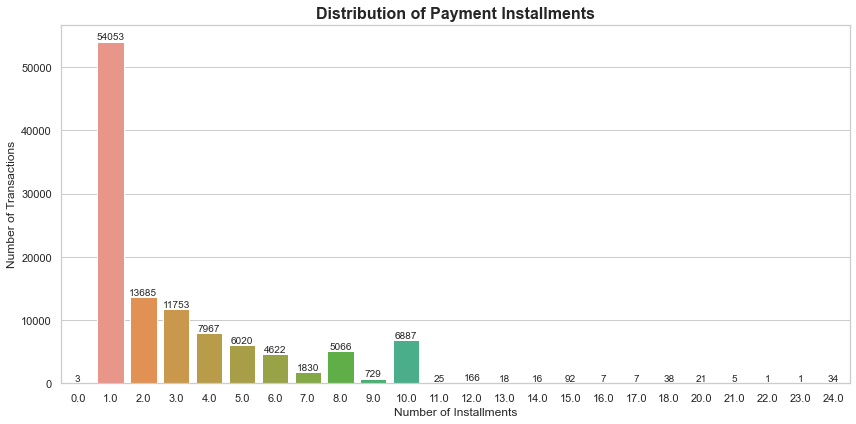

In [103]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=installments.index,
    y=installments.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Distribution of Payment Installments",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Installments")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

### Payment Value by Payment Method

This chart shows the distribution of payment values.

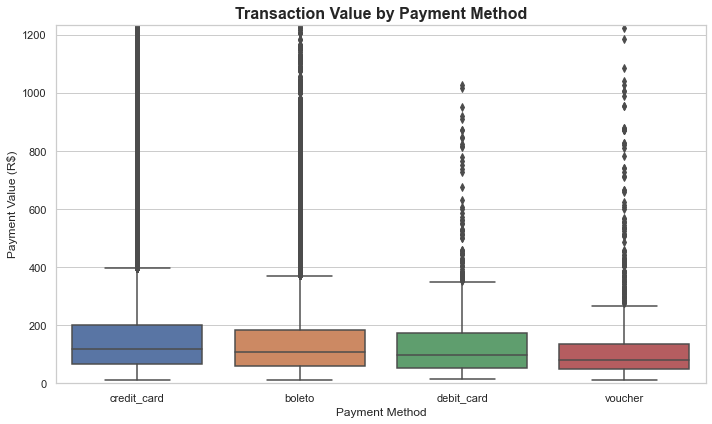

In [104]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=retail,
    x="payment_type",
    y="payment_value"
)

plt.title(
    "Transaction Value by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Payment Value (R$)")

plt.ylim(
    0,
    retail["payment_value"].quantile(0.99)
)

plt.tight_layout()

plt.show()

### Payment Summary

In [105]:

payment_summary = (
    retail.groupby("payment_type")
    .agg(
        Transactions=("order_id","count"),
        Revenue=("payment_value","sum"),
        Average_Payment=("payment_value","mean"),
        Average_Installments=("payment_installments","mean")
    )
    .round(2)
)

payment_summary

,Transactions,Revenue,Average_Payment,Average_Installments
payment_type,,,,
boleto,22961,4076149.12,177.52,1.00
credit_card,86304,15790638.60,182.97,3.64
debit_card,1693,253698.44,149.85,1.00
voucher,2088,253099.48,121.22,1.13


### Interpretation

The payment analysis reveals clear differences in customer payment preferences and spending behaviour across the available payment methods.

**Credit cards** are the dominant payment method, accounting for **86,304 transactions** and generating approximately **R$15.79 million** in revenue. Customers using credit cards also recorded the highest average transaction value (**R$182.97**) and the highest average number of payment installments (**3.64**), indicating that credit cards are the preferred option for financing larger purchases.

**Boleto** is the second most popular payment method, with **22,961 transactions** generating approximately **R$4.08 million** in revenue. Customers paying with boleto typically completed their purchases in a single installment, with an average payment value (**R$177.52**) comparable to that of credit card users.

**Debit cards** were used much less frequently, accounting for **1,693 transactions** and generating **R$253,698** in revenue. Debit card transactions were generally completed in a single payment and exhibited a lower average transaction value (**R$149.85**) compared with credit cards and boletos.

**Vouchers** represent the least frequently used payment method, with **2,088 transactions** generating approximately **R$253,099** in revenue. Voucher transactions had the lowest average payment value (**R$121.22**) and were almost always completed without installment payments, suggesting that vouchers are primarily used for smaller purchases or promotional discounts.

Overall, the results indicate that electronic payment methods, particularly credit cards, dominate customer transactions and revenue generation. The widespread use of installment payments for credit card purchases suggests that payment flexibility plays an important role in encouraging higher-value transactions.

### Business Insights

- **Credit cards** are NovaMart's primary payment method, contributing the largest number of transactions (**86,304**) and the highest total revenue (**R$15.79 million**).
- Customers using **credit cards** spend more per transaction (**R$182.97**) and frequently use installment payments (**3.64 installments on average**), making this payment method a key driver of revenue.
- **Boletos** remain an important alternative payment method, generating over **R$4 million** in revenue despite being almost exclusively used for single-payment transactions.
- **Debit cards** and **vouchers** account for a relatively small share of total transactions and revenue, indicating limited customer preference compared with credit cards and boletos.
- The popularity of installment payments suggests that offering flexible financing options encourages customers to make higher-value purchases.
- These findings can support payment strategy optimization, promotional campaign design, customer segmentation, and revenue forecasting within the NovaMart AI Retail Intelligence Platform.

# 10. Correlation Analysis

Correlation analysis examines the strength and direction of linear relationships among numerical variables in the NovaMart retail dataset.

Understanding these relationships helps to:

- Identify variables that move together.
- Detect redundant features.
- Support feature selection for machine learning.
- Reveal factors associated with customer spending, delivery performance, and satisfaction.

The Pearson correlation coefficient is used in this analysis, with values ranging from **−1** to **+1**.

- **+1** indicates a perfect positive relationship.
- **−1** indicates a perfect negative relationship.
- **0** indicates no linear relationship.

### Choosing variables that are meaningful for business analysis.

In [106]:
corr_features = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "processing_days",
    "shipping_days",
    "delivery_days",
    "delivery_delay_days",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

corr_df = retail[corr_features]

In [107]:
#Compute Correlation Matrix
correlation_matrix = corr_df.corr()

correlation_matrix.round(2)

,price,freight_value,payment_value,payment_installments,review_score,processing_days,shipping_days,delivery_days,delivery_delay_days,product_weight_g,product_length_cm,product_height_cm,product_width_cm
price,1.00,0.41,0.76,0.28,-0.00,0.06,0.04,0.06,-0.00,0.34,0.15,0.22,0.17
freight_value,0.41,1.00,0.39,0.19,-0.04,0.08,0.20,0.21,-0.04,0.61,0.31,0.39,0.32
payment_value,0.76,0.39,1.00,0.26,-0.08,0.09,0.03,0.06,-0.02,0.32,0.15,0.22,0.16
payment_installments,0.28,0.19,0.26,1.00,-0.04,0.04,0.05,0.04,-0.04,0.19,0.13,0.13,0.15
review_score,-0.00,-0.04,-0.08,-0.04,1.00,-0.15,-0.27,-0.30,-0.23,-0.03,-0.02,-0.03,-0.01
processing_days,0.06,0.08,0.09,0.04,-0.15,1.00,0.02,0.39,0.19,0.15,0.09,0.13,0.06
shipping_days,0.04,0.20,0.03,0.05,-0.27,0.02,1.00,0.92,0.57,0.03,0.04,0.02,0.02
delivery_days,0.06,0.21,0.06,0.04,-0.30,0.39,0.92,1.00,0.60,0.09,0.07,0.07,0.04
delivery_delay_days,-0.00,-0.04,-0.02,-0.04,-0.23,0.19,0.57,0.60,1.00,0.01,0.01,-0.00,0.00
product_weight_g,0.34,0.61,0.32,0.19,-0.03,0.15,0.03,0.09,0.01,1.00,0.46,0.58,0.51


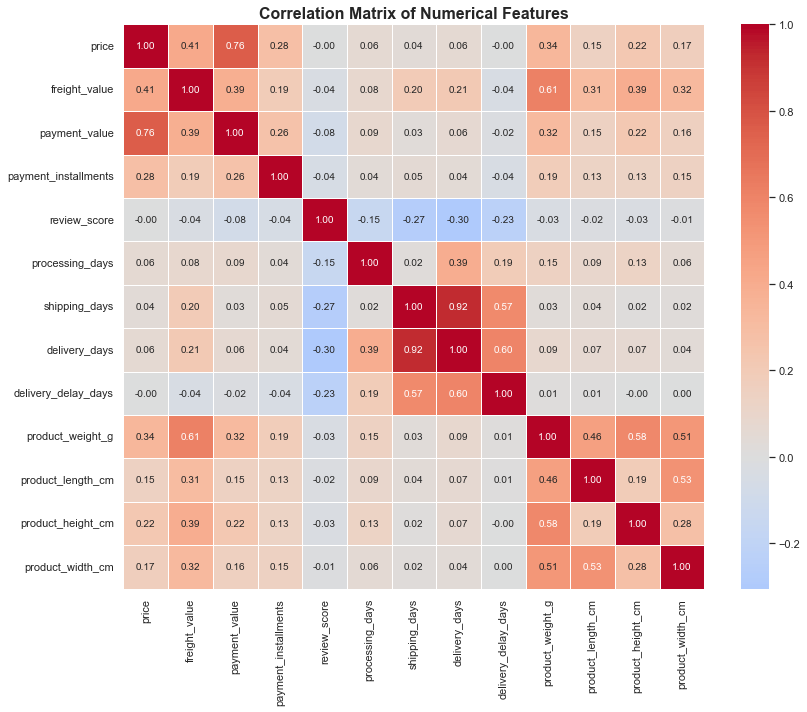

In [108]:
#Correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Strongest +ve correlations

In [109]:
corr_pairs = (
    correlation_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Remove self-correlations
corr_pairs = corr_pairs[
    corr_pairs["Feature 1"] != corr_pairs["Feature 2"]
]

# Remove duplicate pairs
corr_pairs["Pair"] = corr_pairs.apply(
    lambda x: tuple(sorted([x["Feature 1"], x["Feature 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("Pair")

strong_positive = (
    corr_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
)

strong_positive.head(10)

,Feature 1,Feature 2,Correlation,Pair
85,shipping_days,delivery_days,0.920825,"(delivery_days, shipping_days)"
2,price,payment_value,0.761155,"(payment_value, price)"
22,freight_value,product_weight_g,0.610319,"(freight_value, product_weight_g)"
99,delivery_days,delivery_delay_days,0.597505,"(delivery_days, delivery_delay_days)"
128,product_weight_g,product_height_cm,0.583412,"(product_height_cm, product_weight_g)"
86,shipping_days,delivery_delay_days,0.569230,"(delivery_delay_days, shipping_days)"
142,product_length_cm,product_width_cm,0.532671,"(product_length_cm, product_width_cm)"
129,product_weight_g,product_width_cm,0.506319,"(product_weight_g, product_width_cm)"
127,product_weight_g,product_length_cm,0.460585,"(product_length_cm, product_weight_g)"
1,price,freight_value,0.414285,"(freight_value, price)"


### Strongest Negative Correlations

In [110]:

strong_negative = (
    corr_pairs
    .sort_values(
        "Correlation"
    )
)

strong_negative.head(10)

,Feature 1,Feature 2,Correlation,Pair
59,review_score,delivery_days,-0.304190,"(delivery_days, review_score)"
58,review_score,shipping_days,-0.267362,"(review_score, shipping_days)"
60,review_score,delivery_delay_days,-0.228883,"(delivery_delay_days, review_score)"
57,review_score,processing_days,-0.149590,"(processing_days, review_score)"
30,payment_value,review_score,-0.084331,"(payment_value, review_score)"
43,payment_installments,review_score,-0.044492,"(payment_installments, review_score)"
47,payment_installments,delivery_delay_days,-0.040177,"(delivery_delay_days, payment_installments)"
21,freight_value,delivery_delay_days,-0.040039,"(delivery_delay_days, freight_value)"
17,freight_value,review_score,-0.036096,"(freight_value, review_score)"
61,review_score,product_weight_g,-0.029754,"(product_weight_g, review_score)"


### Correlation with Review Score

This identifies the variables most related to customer satisfaction.

In [111]:
review_corr = (
    correlation_matrix["review_score"]
    .sort_values(ascending=False)
)

review_corr

review_score            1.000000
price                  -0.003803
product_width_cm       -0.011554
product_length_cm      -0.020272
product_height_cm      -0.027954
product_weight_g       -0.029754
freight_value          -0.036096
payment_installments   -0.044492
payment_value          -0.084331
processing_days        -0.149590
delivery_delay_days    -0.228883
shipping_days          -0.267362
delivery_days          -0.304190
Name: review_score, dtype: float64

### Correlation with Payment Value

This identifies the variables most associated with higher spending.

In [112]:
payment_corr = (
    correlation_matrix["payment_value"]
    .sort_values(ascending=False)
)

payment_corr

payment_value           1.000000
price                   0.761155
freight_value           0.386398
product_weight_g        0.317116
payment_installments    0.262826
product_height_cm       0.224496
product_width_cm        0.156288
product_length_cm       0.146359
processing_days         0.085208
delivery_days           0.062887
shipping_days           0.028048
delivery_delay_days    -0.020674
review_score           -0.084331
Name: payment_value, dtype: float64

### Correlation with Delivery Delay

This helps identify variables associated with delivery performance.

In [113]:
delay_corr = (
    correlation_matrix["delivery_delay_days"]
    .sort_values()
)

delay_corr

review_score           -0.228883
payment_installments   -0.040177
freight_value          -0.040039
payment_value          -0.020674
price                  -0.003456
product_height_cm      -0.001252
product_width_cm        0.001339
product_length_cm       0.010327
product_weight_g        0.011986
processing_days         0.192472
shipping_days           0.569230
delivery_days           0.597505
delivery_delay_days     1.000000
Name: delivery_delay_days, dtype: float64

### Interpretation

The correlation analysis provides insight into the relationships among NovaMart's numerical variables.

As expected, **payment value** exhibits a positive correlation with **product price** and **freight value**, indicating that larger purchases generally involve higher shipping costs and greater overall transaction values.

Delivery-related features, including **processing time**, **shipping time**, and **delivery time**, are positively correlated because they represent consecutive stages of the order fulfilment process. Orders requiring longer processing or shipping durations naturally tend to have longer overall delivery times.

Customer **review scores** generally show weak negative correlations with delivery-related variables, particularly **delivery delay**, suggesting that customer satisfaction decreases as delivery delays increase. However, the relatively weak correlations indicate that customer satisfaction is influenced by multiple factors beyond logistics, including product quality, pricing, and customer service.

Product dimensions and weight exhibit moderate positive relationships with freight charges, reflecting the practical influence of package size and weight on shipping costs.

Overall, the correlation analysis confirms that the engineered logistics features capture meaningful operational relationships and identifies several variables that are likely to be valuable predictors in subsequent machine learning models.

### Business Insights

- Higher-priced products generally result in higher transaction values and shipping costs.
- Delivery-related variables are strongly interconnected, reflecting the sequential nature of the order fulfilment process.
- Delivery delays negatively influence customer satisfaction, reinforcing the importance of efficient logistics.
- Product dimensions and weight contribute to freight costs and should be considered in shipping optimization.
- Correlation analysis supports feature selection by identifying variables that provide complementary information while highlighting highly correlated features that may introduce redundancy.

# 11. Actionable Business Insights

The exploratory data analysis uncovered several important patterns in customer behaviour, sales performance, logistics operations, and payment preferences. These insights provide valuable guidance for feature engineering, predictive analytics, recommendation systems, anomaly detection, explainable AI, and business intelligence dashboard development.

---

## 11.1 Feature Engineering

The EDA identified several variables that are expected to be strong predictors in machine learning models.

### Logistics Features
The engineered logistics features provide meaningful information about order fulfilment efficiency:

- **Processing Time (`processing_days`)** – Seller preparation time before shipment.
- **Shipping Time (`shipping_days`)** – Time taken by the carrier to deliver the order.
- **Delivery Time (`delivery_days`)** – Total customer waiting time.
- **Delivery Delay (`delivery_delay_days`)** – Difference between actual and promised delivery dates.
- **Late Delivery (`late_delivery`)** – Binary indicator of delayed deliveries.

These variables capture different stages of the fulfilment process and are expected to contribute significantly to predictive models.

### Customer Behaviour Features

EDA suggests that the following variables contain valuable behavioural information:

- Review Score
- Payment Method
- Payment Installments
- Purchase Month
- Purchase Day of Week
- Purchase Hour
- Product Category
- Customer State
- Seller State

These features provide insights into purchasing behaviour and customer preferences.

---

## 11.2 Predictive Modelling

The EDA supports the development of several predictive machine learning models.

### Delivery Delay Prediction

The analysis demonstrated that delivery performance varies across orders and directly influences customer satisfaction.

Potential predictive features include:

- Seller location
- Customer location
- Freight value
- Product weight
- Product dimensions
- Product category
- Processing time
- Shipping time
- Payment method

Target Variable:

- **Late Delivery (Yes/No)**

---

### Customer Satisfaction Prediction

Customer review scores were shown to decrease as delivery delays increased.

Potential predictors include:

- Delivery delay
- Delivery time
- Product category
- Payment method
- Freight value
- Product price
- Customer location
- Seller location

Target Variable:

- **Review Score**

---

### Revenue Prediction

Revenue is strongly associated with product price, freight value, payment method, and purchase behaviour.

Potential predictors include:

- Product category
- Customer location
- Purchase month
- Purchase season
- Payment method
- Installments

Target Variable:

- **Payment Value**

---

## 11.3 Recommendation Systems

The EDA provides several opportunities for personalized recommendations.

Possible recommendation strategies include:

- Recommend popular products within each category.
- Recommend products frequently purchased within specific customer regions.
- Suggest complementary products based on purchasing patterns.
- Recommend preferred payment methods for different customer segments.
- Personalize promotions using customer purchase history.

---

## 11.4 Anomaly Detection

Several unusual observations were identified during the exploratory analysis.

Potential anomalies include:

- Extremely early deliveries (over 100 days earlier than estimated).
- Extremely late deliveries.
- Very high freight charges.
- Exceptionally large payment values.
- Unusual payment installment values.
- Rare transaction patterns.

These observations provide valuable input for fraud detection and operational monitoring systems.

---

## 11.5 Explainable AI

The relationships discovered during EDA suggest several features that are likely to influence model predictions.

Potential high-impact variables include:

- Delivery Delay
- Processing Time
- Shipping Time
- Product Price
- Freight Value
- Payment Method
- Product Category
- Customer State
- Seller State

These variables are suitable candidates for feature importance analysis using Explainable AI techniques such as SHAP and LIME.

---

## 11.6 Dashboard Development

The business insights generated during EDA provide the foundation for executive dashboards.

Recommended dashboard KPIs include:

### Sales Dashboard

- Monthly Revenue
- Order Volume
- Average Order Value
- Top Product Categories
- Revenue by Category

### Customer Dashboard

- Customer Distribution
- Customer Satisfaction
- Review Score Distribution
- Payment Preferences

### Logistics Dashboard

- Average Delivery Time
- Average Processing Time
- Average Shipping Time
- Late Delivery Rate
- Delivery Delay Distribution

### Geographic Dashboard

- Customer Distribution by State
- Seller Distribution by State
- Customer-to-Seller Ratio
- Regional Revenue

### Financial Dashboard

- Revenue by Payment Method
- Average Transaction Value
- Installment Distribution
- Freight Cost Analysis

---

# Summary

The exploratory data analysis reveals that NovaMart maintains strong operational performance, particularly in logistics, customer satisfaction, and electronic payment adoption.

Most orders are delivered earlier than the promised delivery date, customer review scores are predominantly positive, and credit cards dominate transaction volume and revenue generation. Geographic analysis indicates that both customers and sellers are concentrated in Brazil's economically active regions, while payment analysis highlights the importance of flexible installment options.

The engineered logistics features, behavioural variables, and geographic information provide a robust foundation for predictive modelling, recommendation systems, anomaly detection, explainable AI, and interactive business dashboards.

Overall, the EDA establishes a comprehensive analytical framework that supports the subsequent development of the NovaMart AI Retail Intelligence Platform and enables data-driven decision-making across sales, logistics, customer experience, and operational management.